# Model comparison — trend classification across horizons

Compares the trend classifiers on the **OFI** feature stream over the label
horizons **k ∈ {10, 20, 50, 100}**:

| tag | class | family |
|-----|-------|--------|
| `dla + ofi`            | `DLA`            | attention encoder–decoder |
| `tlob + ofi`           | `TLOB`           | temporal/spatial transformer |
| `binctabl + ofi`       | `BINCTABL`       | bilinear + BiN |
| `ctabl + ofi`          | `CTABL`          | bilinear temporal attention |
| `deeplob + ofi`        | `DeepLOB`        | CNN + inception + LSTM |
| `jumpgatelob + ofi`    | `JumpGateLOB`    | jump-diffusion score matching + noise-consistent classifier |
| `alphastablelob + ofi` | `AlphaStableLOB` | α-stable joint diffusion-classifier |

Every model exposes `predict(batch, device) → (B, 3) logits`, so the metrics
(accuracy, macro-F1, per-class F1, confusion) are computed identically.

**Sections**
1. Setup & checkpoint registry (auto-discovered, editable)
2. Load models + build the shared per-horizon test set (incl. per-window realized trend)
3. Overall metrics (accuracy / macro-F1 / per-class F1) across horizons
4. Confusion matrices
5. Metric-vs-horizon curves
6. Extreme conditions (jumps) — performance on turbulent windows
7. Financial / trading metrics — MCC/κ, signal quality, mid-price prediction
   overlay, calibration & confidence gating
8. Final model comparison table

> Run from the **Penny repo root** so the `data/` cache and `checkpoints/`
> relative paths resolve.


## 1. Setup


In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
)
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


# --- locate the repo root and chdir into it -----------------------------------
# Jupyter kernels default their cwd to wherever the server was launched (often
# the notebook's own directory, e.g. `notebooks/`), NOT the repo root. Config
# files store paths like "data/resampled/nobitex" that `build_cache` resolves
# against the *live process cwd* — so if we only add `src/` to sys.path without
# also chdir'ing, imports succeed but data loading fails with a confusing
# "parquet not found" error. Walk up from cwd to find `pyproject.toml` and
# chdir there so every relative path in every config resolves the same way
# regardless of how this notebook was launched.
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(
        f"could not find the Penny repo root (pyproject.toml + src/) above {start}"
    )


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from crypto.dataset import build_datasets  # noqa: E402
from crypto.features import extract_features, n_features  # noqa: E402
from crypto.labels import compute_trend_series  # noqa: E402
from crypto.loader import build_cache  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.binctabl import BINCTABL  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.dla import DLA  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.tlob import TLOB  # noqa: E402
from models.linvar import LinVAR  # noqa: E402
from models.logreg import LogReg  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Registry & checkpoints

`MODELS` maps each tag to its class. `HORIZONS` are the label-`k` values.

`CHECKPOINTS[model][k]` is a path to a checkpoint **directory** (containing
`best.pt`) or the `best.pt` file itself. It is auto-populated by scanning
`CHECKPOINT_ROOT` and reading each run's sibling `config.json` for
`(feature_mode, label_k, symbol)` — the newest run wins. **Edit the printed dict
to point at the exact checkpoints you want.**

In [2]:
FEATURE_MODE = "ofi"
SYMBOL = "USDTIRT"
HORIZONS = [10, 20, 50, 100]
BATCH = 256

# tag -> (class, checkpoint-dir prefix written by the train scripts)
MODELS = {
    "dla": (DLA, "dla_"),
    # "axial": (AxialLOB, "axiallob_"),
    "tlob": (TLOB, "tlob_"),
    "ctabl": (CTABL, "ctabl_"),
    "binctabl": (BINCTABL, "binctabl_"),
    "deeplob": (DeepLOB, "deeplob_"),
    "alphastablelob_1.5": (AlphaStableLOB, "alphastablelob_joint_a1.5_"),
    # "alphastablelob_1.7": (AlphaStableLOB, "alphastablelob_joint_a17"),
    "linvar": (LinVAR, "linvar_"),
    "logreg": (LogReg, "logreg_"),
    "jumpgatelob": (JumpGateLOB, "jumpgatelob_"),
}
LABELS = ["down", "stationary", "up"]
DISPLAY = {m: f"{m} + {FEATURE_MODE}" for m in MODELS}

# where to scan for runs (change if your checkpoints live elsewhere)
CHECKPOINT_ROOT = REPO / "checkpoints" / "nobitex" / SYMBOL

# JSON config used only to BUILD the shared test set for each horizon.
# Any model's ofi config for that k works (identical data params); jumpgatelob
# ships one per horizon.
DATA_CONFIG = "configs/crypto/nobitex/jumpgatelob/usdtirt_{fm}_k{k}.json"


def _run_config(run_dir: Path) -> dict | None:
    """Read a run's sidecar config.json (falls back to best.pt if absent)."""
    cj = run_dir / "config.json"
    if cj.exists():
        try:
            return json.loads(cj.read_text())
        except Exception:
            pass
    bp = run_dir / "best.pt"
    if bp.exists():
        try:
            return torch.load(bp, map_location="cpu", weights_only=False)["config"]
        except Exception:
            pass
    return None


def discover_checkpoints() -> dict:
    """tag -> {k -> newest matching run dir}, matched on prefix + config."""
    found = {m: {} for m in MODELS}
    if not CHECKPOINT_ROOT.exists():
        print(f"! CHECKPOINT_ROOT does not exist: {CHECKPOINT_ROOT}")
        return found
    for run in sorted(CHECKPOINT_ROOT.iterdir()):  # lexical == chronological
        if not run.is_dir():
            continue
        for tag, (_cls, prefix) in MODELS.items():
            if not run.name.startswith(prefix):
                continue
            cfg = _run_config(run)
            if cfg is None:
                continue
            k = cfg.get("label_k")
            if (
                cfg.get("feature_mode") == FEATURE_MODE
                and cfg.get("symbol") == SYMBOL
                and k in HORIZONS
            ):
                found[tag][k] = str(run)  # newest overwrites
    return found


CHECKPOINTS = discover_checkpoints()
print("Auto-discovered checkpoints (edit below if needed):\n")
for m in MODELS:
    row = ", ".join(f"k{k}:{'✓' if k in CHECKPOINTS[m] else '—'}" for k in HORIZONS)
    print(f"  {DISPLAY[m]:<24} {row}")
CHECKPOINTS

Auto-discovered checkpoints (edit below if needed):

  dla + ofi                k10:✓, k20:✓, k50:✓, k100:✓
  tlob + ofi               k10:✓, k20:✓, k50:✓, k100:✓
  ctabl + ofi              k10:✓, k20:✓, k50:✓, k100:✓
  binctabl + ofi           k10:✓, k20:✓, k50:✓, k100:✓
  deeplob + ofi            k10:✓, k20:✓, k50:✓, k100:✓
  alphastablelob_1.5 + ofi k10:✓, k20:✓, k50:✓, k100:✓
  linvar + ofi             k10:✓, k20:✓, k50:✓, k100:✓
  logreg + ofi             k10:✓, k20:✓, k50:✓, k100:✓
  jumpgatelob + ofi        k10:✓, k20:✓, k50:✓, k100:✓


{'dla': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/dla_USDTIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/dla_USDTIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/dla_USDTIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/dla_USDTIRT_ofi_k50'},
 'tlob': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/tlob_USDTIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/tlob_USDTIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/tlob_USDTIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/tlob_USDTIRT_ofi_k50'},
 'ctabl': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/ctabl_USDTIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/USDTIRT/ctabl_USDTIRT_ofi_k100',
  20: '/Us

## 3. Load models & evaluate

The test set is built **once per horizon** and shared across all models, so
every model is scored on the identical windows and labels. For each window we
also record a **stress score** — the repo's own market-jump measure
(`_data_jump_flag`): the largest 1-step increment of the level-averaged feature,
in realized-volatility units. Higher ⇒ more turbulent input.

In [3]:
def load_ckpt(path: str):
    p = Path(path)
    if p.is_dir():
        p = p / "best.pt"
    return torch.load(p, map_location=DEVICE, weights_only=False)


def build_model(tag: str, ckpt: dict):
    cls, _ = MODELS[tag]
    model = cls(ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model


_DS_CACHE: dict[int, tuple] = {}
# META[k] = {"mid", "ts", "centres", "trend", "alpha"} — per-window financial
# ground truth: `centres` indexes each test window's label bin into the full
# `mid`/`ts` series; `trend` is the realized smoothed trend_ratio at that bin
# (the exact quantity the ±alpha label thresholds), used by section 7.
META: dict[int, dict] = {}


def test_set(k: int):
    """(test_ds, y_true, stress) for horizon k — built once, then cached."""
    if k in _DS_CACHE:
        return _DS_CACHE[k]
    cfg_path = REPO / DATA_CONFIG.format(fm=FEATURE_MODE, k=k)
    cfg = json.loads(cfg_path.read_text())
    _, _, test_ds, alpha, meta = build_datasets(cfg)
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    ys, ss = [], []
    for b in loader:
        x = b["x"].float()  # (B, 1, T, F)
        agg = x.squeeze(1).mean(-1)  # (B, T) level-averaged stream
        dif = agg[:, 1:] - agg[:, :-1]
        rv = dif.std(dim=1).clamp_min(1e-8)
        ss.append((dif.abs().max(dim=1).values / rv).numpy())
        ys.append(b["label"].numpy())
    y_true = np.concatenate(ys)
    stress = np.concatenate(ss)

    # financial ground truth: mid series + realized trend at each window centre
    feat, mid, ts = build_cache(cfg, extract_features, n_features, tag="lob")
    centres = np.asarray(test_ds.starts) + cfg["T_past"] - 1
    trend = compute_trend_series(mid, k)[centres]
    lab_chk = np.where(trend > alpha, 2, np.where(trend < -alpha, 0, 1))
    mism = float((lab_chk != y_true).mean())
    if mism > 1e-3:
        print(f"  ! label/trend mismatch {mism:.2%} — check alpha/config alignment")
    META[k] = {"mid": mid, "ts": ts, "centres": centres, "trend": trend, "alpha": alpha}

    print(
        f"  k={k:<3} test windows={len(y_true):>6}  "
        f"class balance {np.bincount(y_true, minlength=3) / len(y_true)}  "
        f"mean |trend|={np.abs(trend).mean() * 1e4:.2f} bp"
    )
    _DS_CACHE[k] = (test_ds, y_true, stress)
    return _DS_CACHE[k]


@torch.no_grad()
def evaluate(model, test_ds):
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    yt, yp, pr = [], [], []
    for b in loader:
        logits = model.predict(b, DEVICE)
        pr.append(Fn.softmax(logits, dim=1).cpu().numpy())
        yp.append(logits.argmax(dim=1).cpu().numpy())
        yt.append(b["label"].numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(pr)

In [4]:
# RESULTS[(tag, k)] = {"y_true", "y_pred", "probs", "stress"}
RESULTS: dict = {}

for k in HORIZONS:
    print(f"horizon k={k}")
    try:
        test_ds, y_true, stress = test_set(k)
    except FileNotFoundError as e:
        print(f"  ! could not build test set for k={k}: {e}")
        print(
            f"    (cwd is {Path.cwd()} — if this looks wrong, re-run the setup "
            f"cell; if the file is genuinely missing, run `uv run dvc pull`)"
        )
        continue
    except Exception as e:
        print(f"  ! could not build test set for k={k}: {e}")
        continue
    for tag in MODELS:
        path = CHECKPOINTS.get(tag, {}).get(k)
        if not path or not Path(path).exists():
            print(f"  {DISPLAY[tag]:<24} — no checkpoint, skipped")
            continue
        ckpt = load_ckpt(path)
        cfg = ckpt["config"]
        if cfg.get("label_k") != k or cfg.get("feature_mode") != FEATURE_MODE:
            print(
                f"  {DISPLAY[tag]:<24} ! config mismatch "
                f"(k={cfg.get('label_k')}, fm={cfg.get('feature_mode')}), skipped"
            )
            continue
        model = build_model(tag, ckpt)
        yt, yp, pr = evaluate(model, test_ds)
        assert np.array_equal(yt, y_true), "window/label misalignment"
        RESULTS[(tag, k)] = {"y_true": yt, "y_pred": yp, "probs": pr, "stress": stress}
        acc = (yt == yp).mean()
        f1 = f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0)
        print(f"  {DISPLAY[tag]:<24} acc={acc:.4f}  macro_f1={f1:.4f}")
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

print(f"\nevaluated {len(RESULTS)} (model, horizon) pairs")

2026-07-22 14:07:17.844 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,448 rows, 31 features


horizon k=10


2026-07-22 14:07:19.503 | INFO     | crypto.dataset:build_datasets:85 - windows — train:147257 val:31847 test:31949
2026-07-22 14:07:19.746 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,448 rows, 31 features


  k=10  test windows= 31949  class balance [0.30123009 0.3774453  0.32132461]  mean |trend|=2.50 bp
  dla + ofi                acc=0.6513  macro_f1=0.6530
  tlob + ofi               acc=0.6324  macro_f1=0.6330
  ctabl + ofi              acc=0.6425  macro_f1=0.6441
  binctabl + ofi           acc=0.6249  macro_f1=0.6266
  deeplob + ofi            acc=0.5903  macro_f1=0.5888
  alphastablelob_1.5 + ofi acc=0.6475  macro_f1=0.6493
  linvar + ofi             acc=0.6339  macro_f1=0.6360
  logreg + ofi             acc=0.6298  macro_f1=0.6315


2026-07-22 14:09:22.230 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,448 rows, 31 features


...

  k=50  test windows= 31909  class balance [0.29612335 0.36431728 0.33955937]  mean |trend|=5.37 bp
  dla + ofi                acc=0.5865  macro_f1=0.5883
  tlob + ofi               acc=0.5500  macro_f1=0.5535
  ctabl + ofi              acc=0.5816  macro_f1=0.5813
  binctabl + ofi           acc=0.5508  macro_f1=0.5504
  deeplob + ofi            acc=0.5309  macro_f1=0.5160
  alphastablelob_1.5 + ofi acc=0.5635  macro_f1=0.5687
  linvar + ofi             acc=0.5761  macro_f1=0.5738
  logreg + ofi             acc=0.5735  macro_f1=0.5716


2026-07-22 14:13:30.683 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,448 rows, 31 features


  jumpgatelob + ofi        acc=0.5710  macro_f1=0.5721
horizon k=100


2026-07-22 14:13:32.264 | INFO     | crypto.dataset:build_datasets:85 - windows — train:147126 val:31757 test:31859
2026-07-22 14:13:32.527 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,448 rows, 31 features


  k=100 test windows= 31859  class balance [0.2997897  0.36030635 0.33990395]  mean |trend|=7.37 bp
  dla + ofi                acc=0.5573  macro_f1=0.5562
  tlob + ofi               acc=0.5256  macro_f1=0.5196
  ctabl + ofi              acc=0.5447  macro_f1=0.5422
  binctabl + ofi           acc=0.5107  macro_f1=0.5110
  deeplob + ofi            acc=0.5211  macro_f1=0.5161
  alphastablelob_1.5 + ofi acc=0.5369  macro_f1=0.5401
  linvar + ofi             acc=0.5524  macro_f1=0.5484
  logreg + ofi             acc=0.5467  macro_f1=0.5425
  jumpgatelob + ofi        acc=0.5329  macro_f1=0.5274

evaluated 36 (model, horizon) pairs


## 4. Overall metrics

In [5]:
def metrics_row(yt, yp):
    per_f1 = f1_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        "accuracy": (yt == yp).mean(),
        "macro_f1": f1_score(
            yt, yp, average="macro", labels=[0, 1, 2], zero_division=0
        ),
        "f1_down": per_f1[0],
        "f1_stat": per_f1[1],
        "f1_up": per_f1[2],
    }


rows = []
for (tag, k), r in RESULTS.items():
    rows.append(
        {"model": DISPLAY[tag], "k": k, **metrics_row(r["y_true"], r["y_pred"])}
    )

metrics_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
metrics_df

,model,k,accuracy,macro_f1,f1_down,f1_stat,f1_up
0,alphastablelob_1.5 + ofi,10,0.6475,0.6493,0.6595,0.6133,0.6751
1,binctabl + ofi,10,0.6249,0.6266,0.6363,0.5889,0.6545
2,ctabl + ofi,10,0.6425,0.6441,0.6528,0.6087,0.6706
3,deeplob + ofi,10,0.5903,0.5888,0.5765,0.5709,0.6188
4,dla + ofi,10,0.6513,0.6530,0.6616,0.6143,0.6831
5,jumpgatelob + ofi,10,0.6283,0.6290,0.6355,0.5882,0.6634
6,linvar + ofi,10,0.6339,0.6360,0.6457,0.5992,0.6630
7,logreg + ofi,10,0.6298,0.6315,0.6378,0.5970,0.6595
8,tlob + ofi,10,0.6324,0.6330,0.6405,0.5872,0.6713
9,alphastablelob_1.5 + ofi,20,0.5990,0.6007,0.6076,0.5358,0.6586


In [6]:
# accuracy & macro-F1 pivots (rows = model, cols = horizon)
if not metrics_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric in ["accuracy", "macro_f1"]:
        piv = metrics_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== accuracy (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.6513,0.6206,0.5865,0.5573
tlob + ofi,0.6324,0.5817,0.5500,0.5256
ctabl + ofi,0.6425,0.6045,0.5816,0.5447
binctabl + ofi,0.6249,0.5768,0.5508,0.5107
deeplob + ofi,0.5903,0.5376,0.5309,0.5211
alphastablelob_1.5 + ofi,0.6475,0.5990,0.5635,0.5369
linvar + ofi,0.6339,0.6023,0.5761,0.5524
logreg + ofi,0.6298,0.5956,0.5735,0.5467
jumpgatelob + ofi,0.6283,0.5881,0.5710,0.5329



=== macro_f1 (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.6530,0.6238,0.5883,0.5562
tlob + ofi,0.6330,0.5827,0.5535,0.5196
ctabl + ofi,0.6441,0.6074,0.5813,0.5422
binctabl + ofi,0.6266,0.5792,0.5504,0.5110
deeplob + ofi,0.5888,0.5363,0.5160,0.5161
alphastablelob_1.5 + ofi,0.6493,0.6007,0.5687,0.5401
linvar + ofi,0.6360,0.6047,0.5738,0.5484
logreg + ofi,0.6315,0.5974,0.5716,0.5425
jumpgatelob + ofi,0.6290,0.5884,0.5721,0.5274


## 5. Confusion matrices

Row-normalized (recall per true class). One row of panels per horizon.

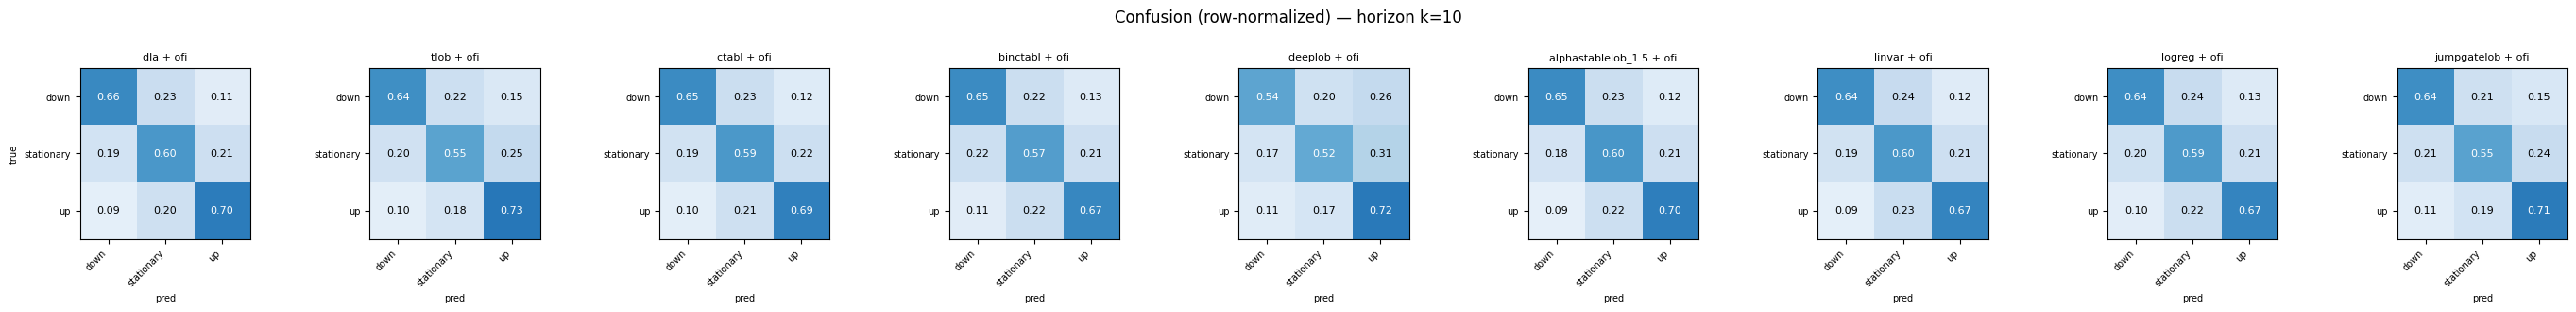

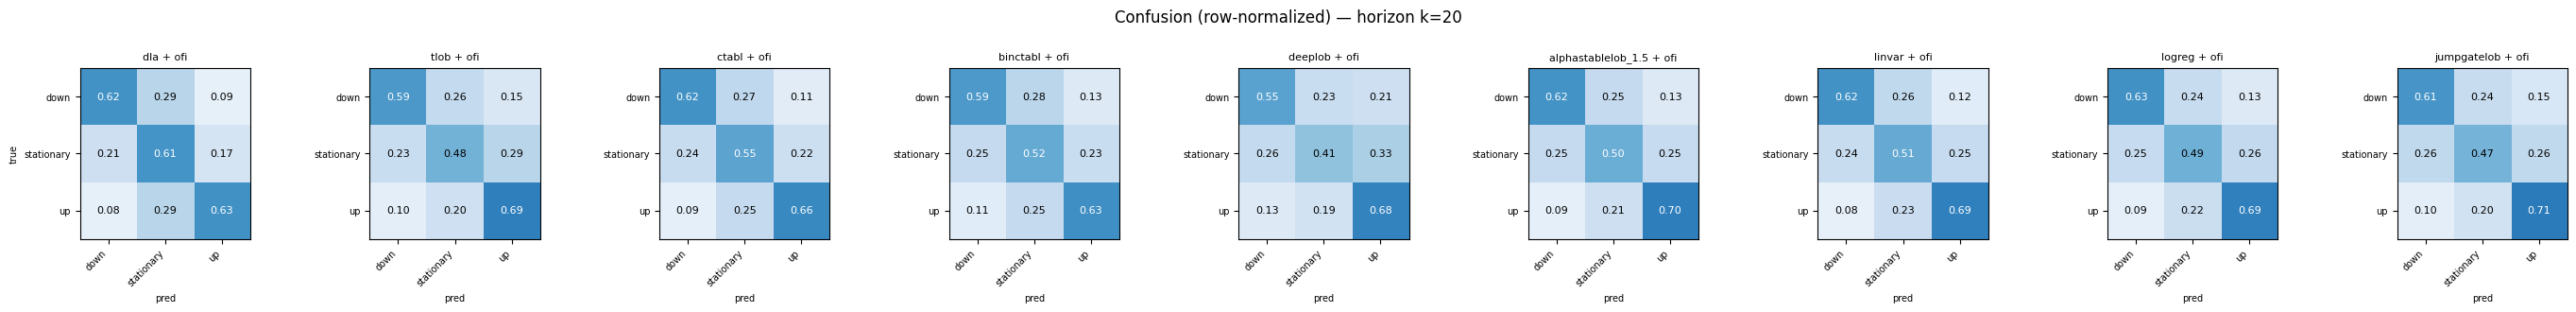

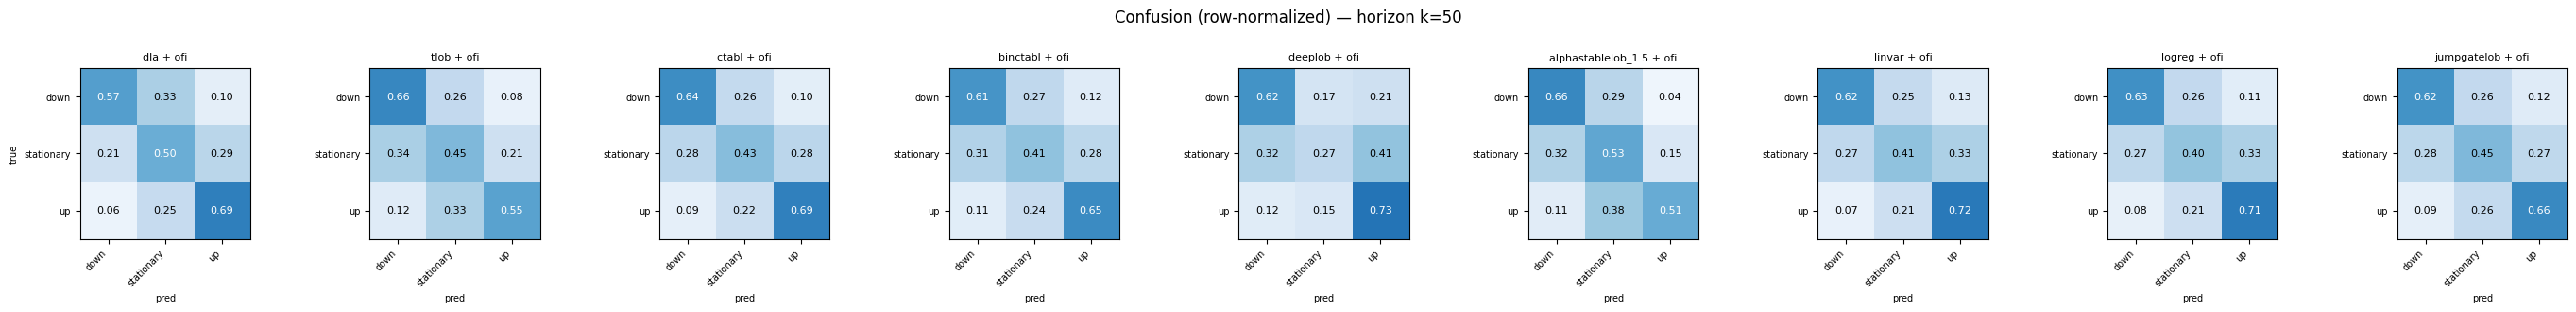

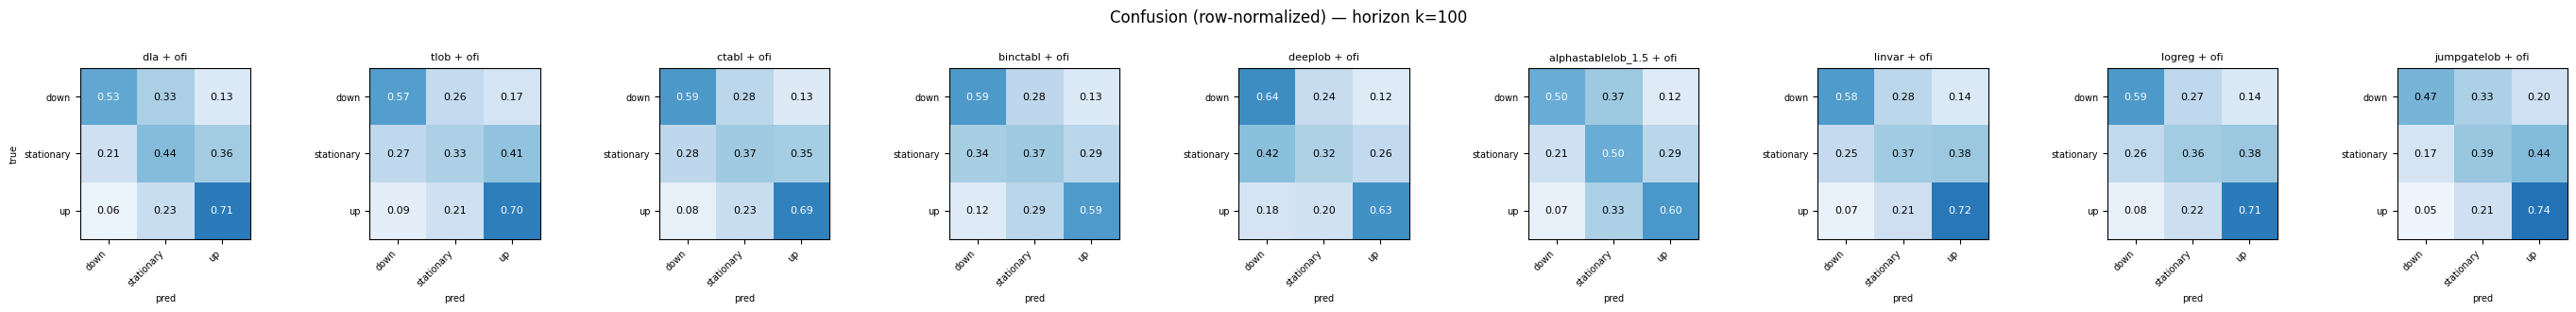

In [7]:
def plot_confusions(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return
    fig, axes = plt.subplots(
        1, len(tags), figsize=(3.1 * len(tags), 3.0), squeeze=False
    )
    for ax, tag in zip(axes[0], tags):
        r = RESULTS[(tag, k)]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=[0, 1, 2]).astype(float)
        cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
        _ = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(
                    j,
                    i,
                    f"{cmn[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if cmn[i, j] > 0.5 else "black",
                    fontsize=8,
                )
        ax.set_xticks(range(3), LABELS, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(3), LABELS, fontsize=7)
        ax.set_title(DISPLAY[tag], fontsize=8)
        ax.set_xlabel("pred", fontsize=7)
    axes[0][0].set_ylabel("true", fontsize=7)
    fig.suptitle(f"Confusion (row-normalized) — horizon k={k}", y=1.04)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_confusions(k)

## 6. Metric vs horizon

How each model's accuracy and macro-F1 evolve as the prediction horizon grows.

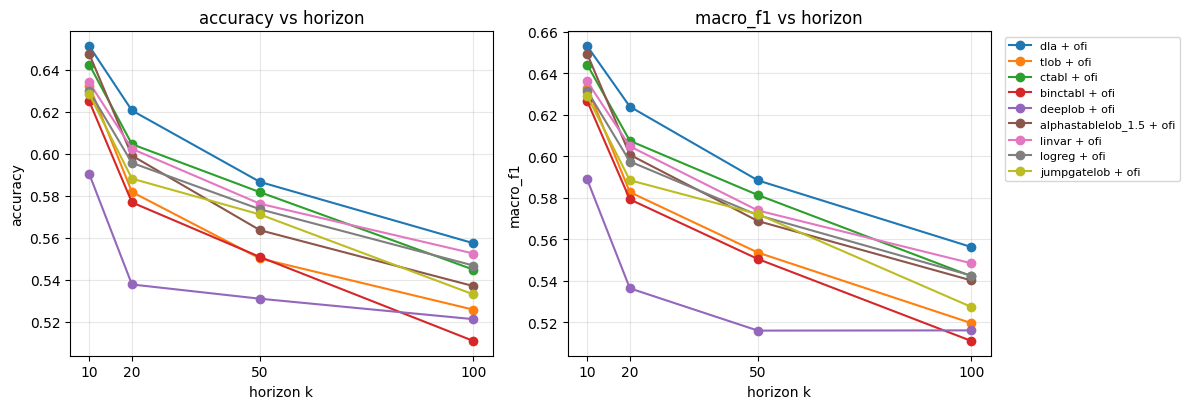

In [8]:
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    cmap = plt.get_cmap("tab10")
    present = [m for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric, ax in zip(["accuracy", "macro_f1"], axes):
        for i, tag in enumerate(present):
            sub = metrics_df[metrics_df["model"] == DISPLAY[tag]].sort_values("k")
            ax.plot(sub["k"], sub[metric], "o-", color=cmap(i % 10), label=DISPLAY[tag])
        ax.set_xlabel("horizon k")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs horizon")
        ax.set_xticks(HORIZONS)
        ax.grid(alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

## 7. Extreme conditions (jumps)

Windows are split by their **stress score** (RV-normalized max increment). We
compare performance on **calm** vs **extreme** windows, where *extreme* = the top
`EXTREME_Q` quantile of stress **within each horizon** (guarantees non-empty
buckets). A large `Δ = calm − extreme` means a model degrades under turbulence;
a small Δ means it is jump-robust.

In [9]:
EXTREME_Q = 0.90  # top 10% most turbulent windows = "extreme"


def split_metrics(r, thr):
    st = r["stress"]
    calm, extr = st <= thr, st > thr
    out = {}
    for name, mask in [("calm", calm), ("extreme", extr)]:
        if mask.sum() == 0:
            out[name] = {"n": 0, "accuracy": np.nan, "macro_f1": np.nan}
            continue
        yt, yp = r["y_true"][mask], r["y_pred"][mask]
        out[name] = {
            "n": int(mask.sum()),
            "accuracy": (yt == yp).mean(),
            "macro_f1": f1_score(
                yt, yp, average="macro", labels=[0, 1, 2], zero_division=0
            ),
        }
    return out


rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    s = split_metrics(r, thr)
    rows.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "acc_calm": s["calm"]["accuracy"],
            "acc_extreme": s["extreme"]["accuracy"],
            "f1_calm": s["calm"]["macro_f1"],
            "f1_extreme": s["extreme"]["macro_f1"],
            "f1_drop": s["calm"]["macro_f1"] - s["extreme"]["macro_f1"],
            "n_extreme": s["extreme"]["n"],
        }
    )
extreme_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
extreme_df

,model,k,acc_calm,acc_extreme,f1_calm,f1_extreme,f1_drop,n_extreme
0,alphastablelob_1.5 + ofi,10,0.6469,0.6529,0.6486,0.6548,-0.0062,3195
1,binctabl + ofi,10,0.6242,0.6319,0.6258,0.6337,-0.0079,3195
2,ctabl + ofi,10,0.6413,0.6532,0.6429,0.6544,-0.0115,3195
3,deeplob + ofi,10,0.5893,0.5997,0.5877,0.5979,-0.0102,3195
4,dla + ofi,10,0.6496,0.6664,0.6513,0.6681,-0.0168,3195
5,jumpgatelob + ofi,10,0.6249,0.6588,0.6257,0.6592,-0.0336,3195
6,linvar + ofi,10,0.6316,0.6551,0.6336,0.6576,-0.0241,3195
7,logreg + ofi,10,0.6275,0.6501,0.6292,0.6516,-0.0224,3195
8,tlob + ofi,10,0.6318,0.6376,0.6324,0.6384,-0.0061,3195
9,alphastablelob_1.5 + ofi,20,0.5965,0.6224,0.5982,0.6225,-0.0242,3194


In [10]:
# macro-F1 drop under stress (rows=model, cols=horizon) — lower is more robust
if not extreme_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(extreme_df["model"])]
    piv = extreme_df.pivot(index="model", columns="k", values="f1_drop").reindex(order)
    print("=== macro-F1 drop (calm − extreme); lower = more jump-robust ===")
    display(piv.style.background_gradient(cmap="Reds", axis=None).format("{:.4f}"))

=== macro-F1 drop (calm − extreme); lower = more jump-robust ===


k,10,20,50,100
model,,,,
dla + ofi,-0.0168,-0.0165,-0.0201,-0.0179
tlob + ofi,-0.0061,-0.0216,-0.0272,-0.0855
ctabl + ofi,-0.0115,-0.0121,-0.0331,-0.0387
binctabl + ofi,-0.0079,-0.0272,-0.0400,-0.0741
deeplob + ofi,-0.0102,-0.0398,-0.0198,-0.0395
alphastablelob_1.5 + ofi,-0.0062,-0.0242,-0.0549,-0.0570
linvar + ofi,-0.0241,-0.0249,-0.0310,-0.0205
logreg + ofi,-0.0224,-0.0350,-0.0427,-0.0278
jumpgatelob + ofi,-0.0336,-0.0337,-0.0521,-0.0670


### Accuracy vs stress decile

Windows binned into stress deciles; per-model accuracy in each bin. The right side of each panel is the turbulent regime.

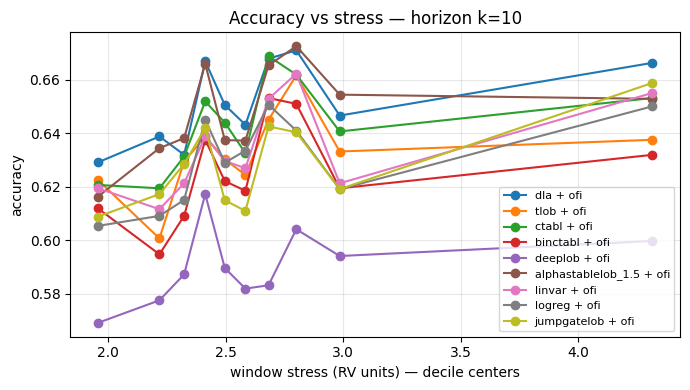

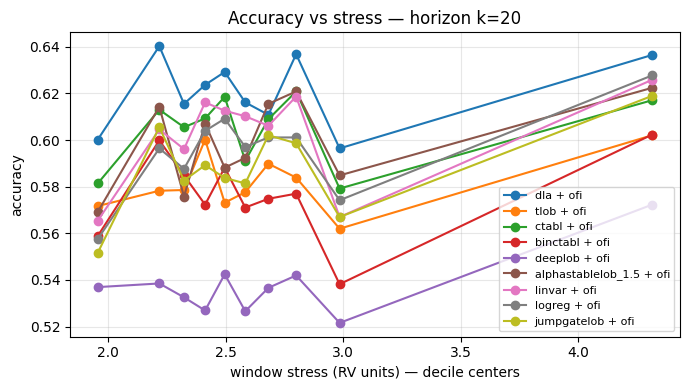

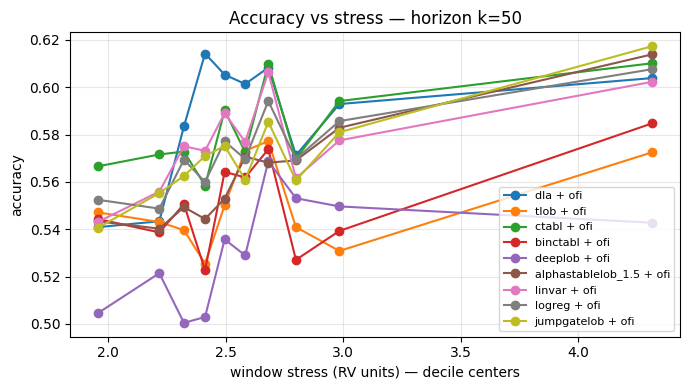

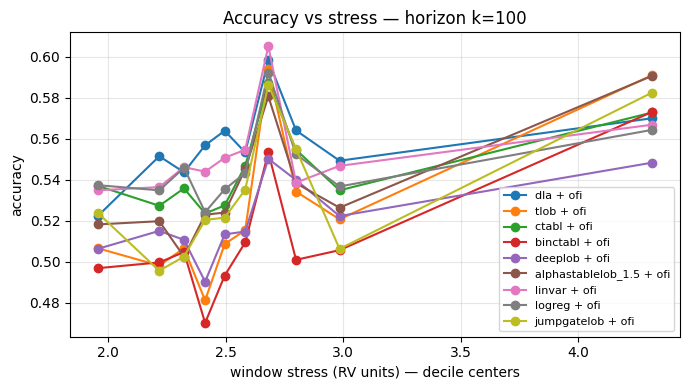

In [11]:
def plot_stress_curves(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return None
    stress = RESULTS[(tags[0], k)]["stress"]
    edges = np.quantile(stress, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers = 0.5 * (edges[:-1] + edges[1:])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        idx = np.clip(np.digitize(r["stress"], edges) - 1, 0, n_bins - 1)
        acc = [
            correct[idx == b].mean() if (idx == b).any() else np.nan
            for b in range(n_bins)
        ]
        ax.plot(centers, acc, "o-", color=cmap(i % 10), label=DISPLAY[tag])
    ax.set_xlabel("window stress (RV units) — decile centers")
    ax.set_ylabel("accuracy")
    ax.set_title(f"Accuracy vs stress — horizon k={k}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_stress_curves(k)

### Catching the big moves

In the extreme bucket, per-class **recall** for `down` and `up` — does the model still flag large directional moves when they happen?

In [12]:
rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    mask = r["stress"] > thr
    if mask.sum() == 0:
        continue
    yt, yp = r["y_true"][mask], r["y_pred"][mask]
    rec = recall_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    rows.append(
        {"model": DISPLAY[tag], "k": k, "recall_down": rec[0], "recall_up": rec[2]}
    )
recall_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
recall_df

,model,k,recall_down,recall_up
0,alphastablelob_1.5 + ofi,10,0.6706,0.6819
1,binctabl + ofi,10,0.6256,0.6495
2,ctabl + ofi,10,0.6432,0.6952
3,deeplob + ofi,10,0.5318,0.7105
4,dla + ofi,10,0.6755,0.6943
5,jumpgatelob + ofi,10,0.6608,0.7190
6,linvar + ofi,10,0.6432,0.6733
7,logreg + ofi,10,0.6481,0.6857
8,tlob + ofi,10,0.6237,0.7095
9,alphastablelob_1.5 + ofi,20,0.5976,0.7201


## 7b. Financial / trading metrics

Classification scores alone don't say whether signals are *tradeable*. Everything
here is computed against the **realized smoothed trend** `trend_ratio` of each test
window — the exact quantity the ±α labels threshold — so it is a cost-free proxy for
signal quality, **not a trading simulation** (no positions, costs, or fills; that
comes later):

- **MCC & Cohen's κ** — chance-corrected agreement, the headline metrics of recent
  LOB benchmarks (robust to class imbalance, unlike accuracy).
- **Signal rate / directional hit rate** — how often a model calls a direction, and
  the per-signal win rate when it does.
- **Directional capture** — mean signed trend captured per window (bp):
  `+trend` on up-calls, `−trend` on down-calls, `0` on flat.
  `capture_ratio` = captured / oracle (oracle = always right on every window).


In [13]:
def _positions(yp):
    """Predicted position per window: up → +1, down → −1, flat → 0."""
    return np.where(yp == 2, 1, np.where(yp == 0, -1, 0))


fin_rows = []
for (tag, k), r in RESULTS.items():
    m = META.get(k)
    if m is None:
        continue
    yt, yp = r["y_true"], r["y_pred"]
    tr = np.nan_to_num(m["trend"])
    pos = _positions(yp)
    cap = pos * tr
    d = pos != 0
    fin_rows.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "mcc": matthews_corrcoef(yt, yp),
            "kappa": cohen_kappa_score(yt, yp),
            "signal_rate": d.mean(),
            "hit_rate": (np.sign(tr[d]) == pos[d]).mean() if d.any() else np.nan,
            "capture_bp_win": cap.mean() * 1e4,
            "capture_bp_signal": cap[d].mean() * 1e4 if d.any() else np.nan,
            "oracle_bp_win": np.abs(tr).mean() * 1e4,
            "capture_ratio": cap.mean() / max(np.abs(tr).mean(), 1e-12),
        }
    )
fin_df = pd.DataFrame(fin_rows).sort_values(["k", "model"]).reset_index(drop=True)
fin_df

,model,k,mcc,kappa,signal_rate,hit_rate,capture_bp_win,capture_bp_signal,oracle_bp_win,capture_ratio
0,alphastablelob_1.5 + ofi,10,0.4694,0.4692,0.6354,0.8086,1.5873,2.4983,2.4992,0.6352
1,binctabl + ofi,10,0.4364,0.4361,0.6462,0.7852,1.5275,2.3636,2.4992,0.6112
2,ctabl + ofi,10,0.4622,0.4620,0.6403,0.8001,1.5673,2.4478,2.4992,0.6271
3,deeplob + ofi,10,0.3899,0.3853,0.6875,0.7255,1.3255,1.9278,2.4992,0.5304
4,dla + ofi,10,0.4753,0.4751,0.6384,0.8128,1.6090,2.5203,2.4992,0.6438
5,jumpgatelob + ofi,10,0.4435,0.4421,0.6694,0.7784,1.5445,2.3072,2.4992,0.6180
6,linvar + ofi,10,0.4484,0.4484,0.6267,0.8037,1.5594,2.4883,2.4992,0.6240
7,logreg + ofi,10,0.4427,0.4426,0.6346,0.7917,1.5410,2.4284,2.4992,0.6166
8,tlob + ofi,10,0.4498,0.4481,0.6701,0.7872,1.5724,2.3464,2.4992,0.6292
9,alphastablelob_1.5 + ofi,20,0.3991,0.3980,0.6649,0.7894,2.1235,3.1939,3.4093,0.6229


In [14]:
# MCC and capture-ratio pivots (rows = model, cols = horizon)
if not fin_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(fin_df["model"])]
    for metric in ["mcc", "capture_ratio", "hit_rate"]:
        piv = fin_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== mcc (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.4753,0.4264,0.3768,0.3347
tlob + ofi,0.4498,0.3743,0.3274,0.2924
ctabl + ofi,0.4622,0.4043,0.3738,0.3186
binctabl + ofi,0.4364,0.3631,0.3278,0.2678
deeplob + ofi,0.3899,0.3127,0.3101,0.2911
alphastablelob_1.5 + ofi,0.4694,0.3991,0.3479,0.3013
linvar + ofi,0.4484,0.4027,0.3663,0.3308
logreg + ofi,0.4427,0.3944,0.3623,0.3227
jumpgatelob + ofi,0.4435,0.3850,0.3564,0.3011



=== capture_ratio (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.6438,0.6142,0.6342,0.6162
tlob + ofi,0.6292,0.5983,0.5969,0.5925
ctabl + ofi,0.6271,0.6108,0.6535,0.6211
binctabl + ofi,0.6112,0.5734,0.6054,0.5464
deeplob + ofi,0.5304,0.5284,0.5905,0.5623
alphastablelob_1.5 + ofi,0.6352,0.6229,0.5937,0.5431
linvar + ofi,0.6240,0.6325,0.6516,0.6360
logreg + ofi,0.6166,0.6245,0.6565,0.6274
jumpgatelob + ofi,0.6180,0.6124,0.6223,0.5751



=== hit_rate (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.8128,0.8209,0.8189,0.7988
tlob + ofi,0.7872,0.7740,0.7830,0.7572
ctabl + ofi,0.8001,0.7982,0.8025,0.7862
binctabl + ofi,0.7852,0.7713,0.7725,0.7509
deeplob + ofi,0.7255,0.7217,0.7342,0.7389
alphastablelob_1.5 + ofi,0.8086,0.7894,0.8144,0.7851
linvar + ofi,0.8037,0.8037,0.7964,0.7883
logreg + ofi,0.7917,0.7880,0.8013,0.7878
jumpgatelob + ofi,0.7784,0.7756,0.7930,0.7652


### Mid-price path vs model predictions

The mid-price over the most active stretch of the test period, with **true**
up/down regimes shaded (green = up, red = down, white = flat). Each strip below is
one model's predicted label over the same windows — you can see directly *where*
each model catches or misses the moves. Change `seg_len`/`start` to zoom.


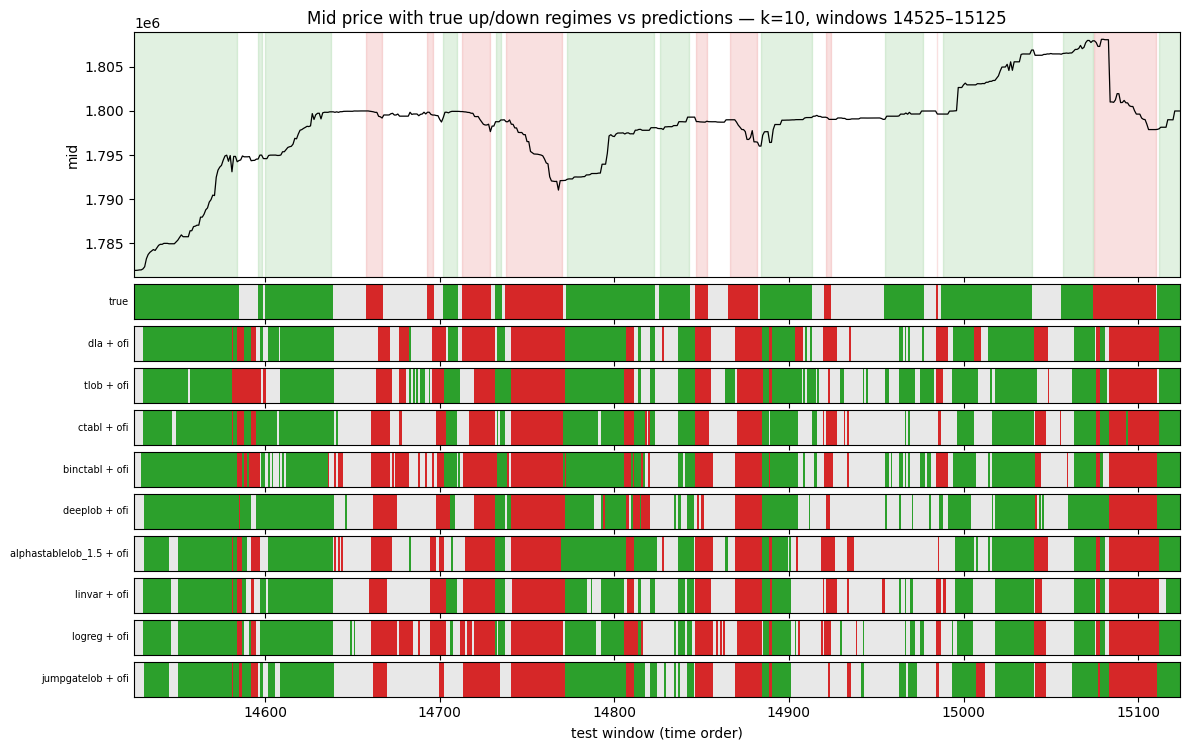

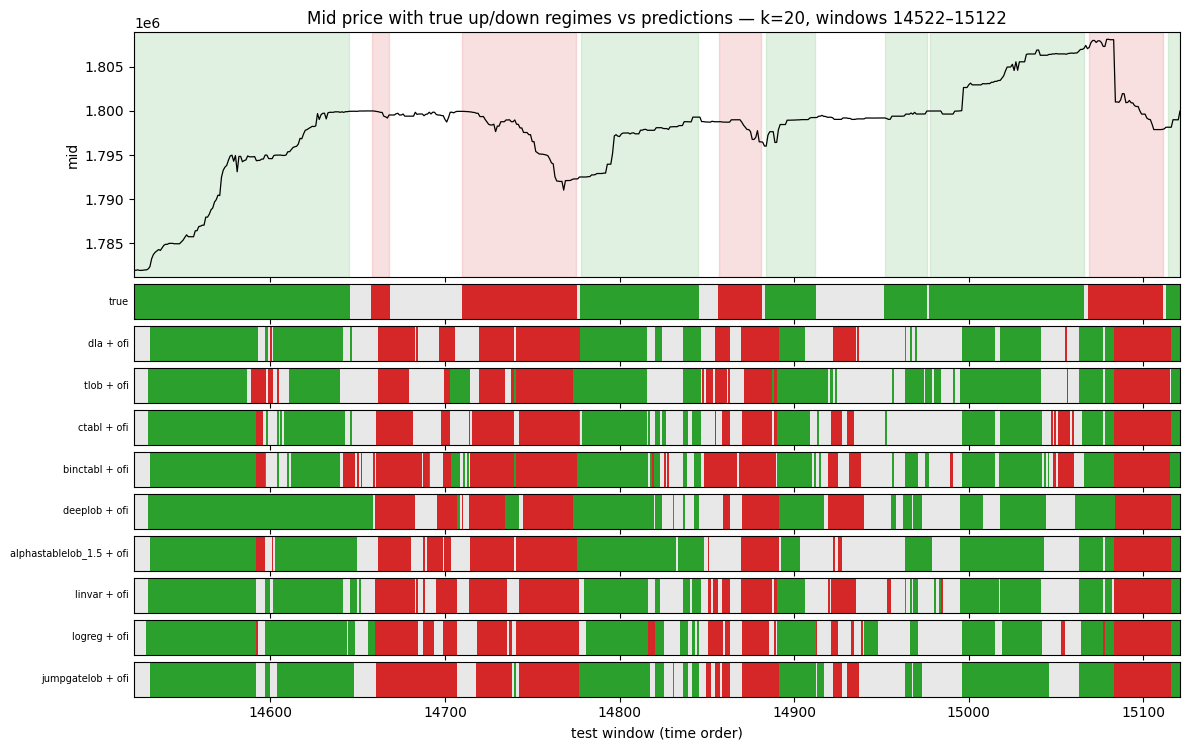

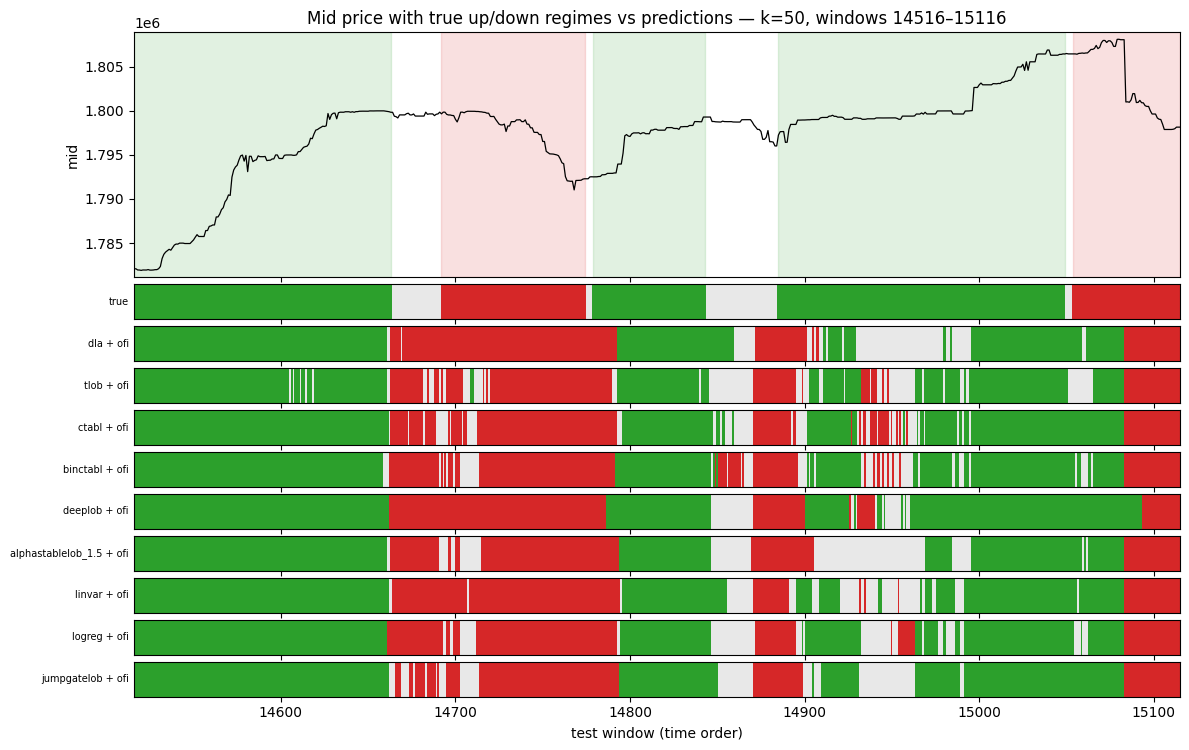

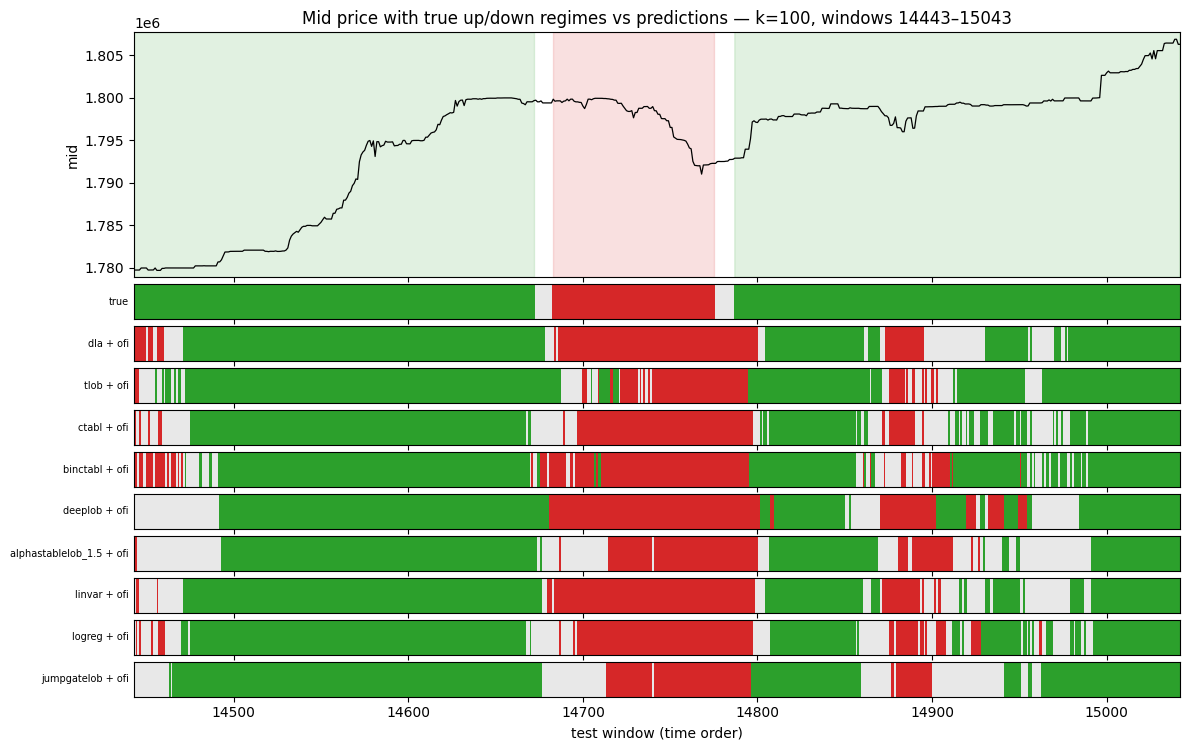

In [15]:
LAB_CMAP = ListedColormap(["#d62728", "#e8e8e8", "#2ca02c"])  # down / flat / up


def plot_price_predictions(k, seg_len=600, start=None):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    y_true = RESULTS[(tags[0], k)]["y_true"]
    tr = np.nan_to_num(m["trend"])
    seg_len = min(seg_len, len(y_true))
    if start is None:  # auto-pick the stretch with the most |trend| mass
        act = np.convolve(np.abs(tr), np.ones(seg_len), "valid")
        start = int(act.argmax())
    sl = slice(start, start + seg_len)
    idx = np.arange(start, start + seg_len)
    price = m["mid"][m["centres"][sl]]
    yt_seg = y_true[sl]

    lanes = [("true", yt_seg)] + [
        (DISPLAY[t], RESULTS[(t, k)]["y_pred"][sl]) for t in tags
    ]
    fig, axes = plt.subplots(
        1 + len(lanes),
        1,
        figsize=(12, 3.4 + 0.42 * len(lanes)),
        sharex=True,
        gridspec_kw={"height_ratios": [7] + [1] * len(lanes)},
    )
    ax = axes[0]
    ax.plot(idx, price, lw=0.9, color="black")
    lo, hi = price.min(), price.max()
    pad = 0.03 * (hi - lo + 1e-9)
    ax.fill_between(
        idx,
        lo - pad,
        hi + pad,
        where=yt_seg == 2,
        color="#2ca02c",
        alpha=0.14,
        step="mid",
    )
    ax.fill_between(
        idx,
        lo - pad,
        hi + pad,
        where=yt_seg == 0,
        color="#d62728",
        alpha=0.14,
        step="mid",
    )
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_ylabel("mid")
    ax.set_title(
        f"Mid price with true up/down regimes vs predictions — "
        f"k={k}, windows {start}–{start + seg_len}"
    )
    for axl, (name, lab) in zip(axes[1:], lanes):
        axl.imshow(
            lab[None, :],
            aspect="auto",
            cmap=LAB_CMAP,
            vmin=0,
            vmax=2,
            extent=[idx[0], idx[-1], 0, 1],
            interpolation="nearest",
        )
        axl.set_yticks([])
        axl.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=7)
    axes[-1].set_xlabel("test window (time order)")
    fig.tight_layout(h_pad=0.15)
    plt.show()


for k in HORIZONS:
    plot_price_predictions(k)

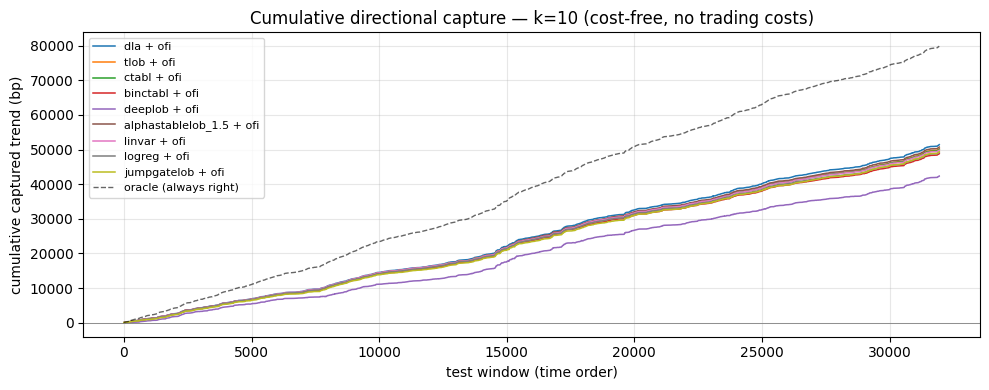

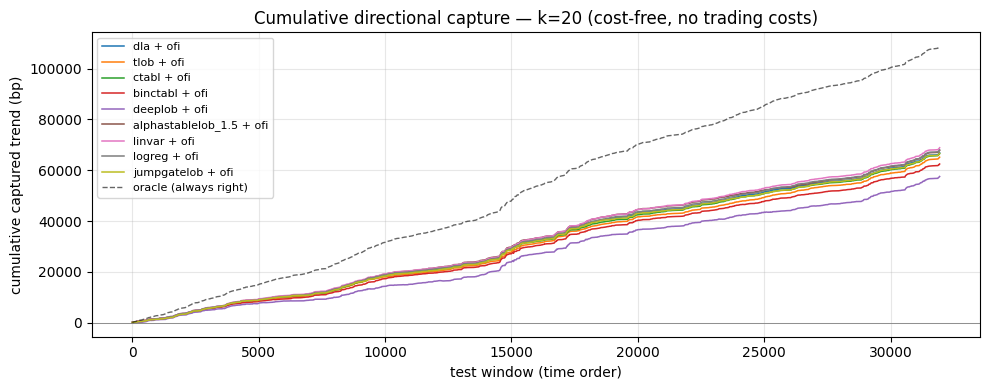

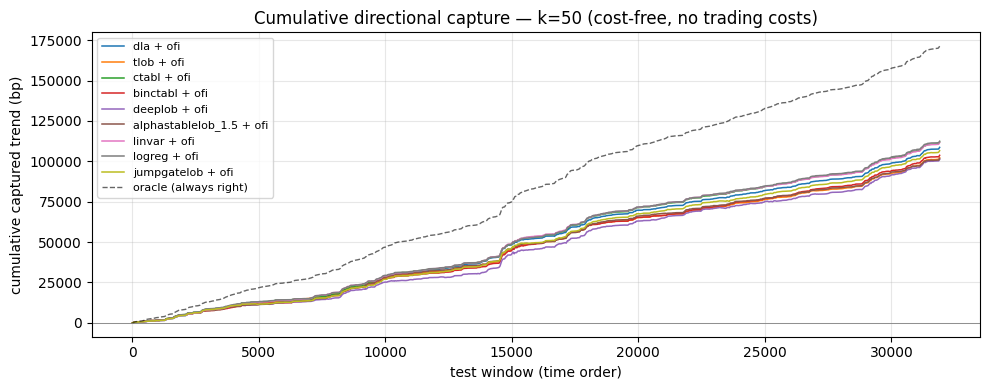

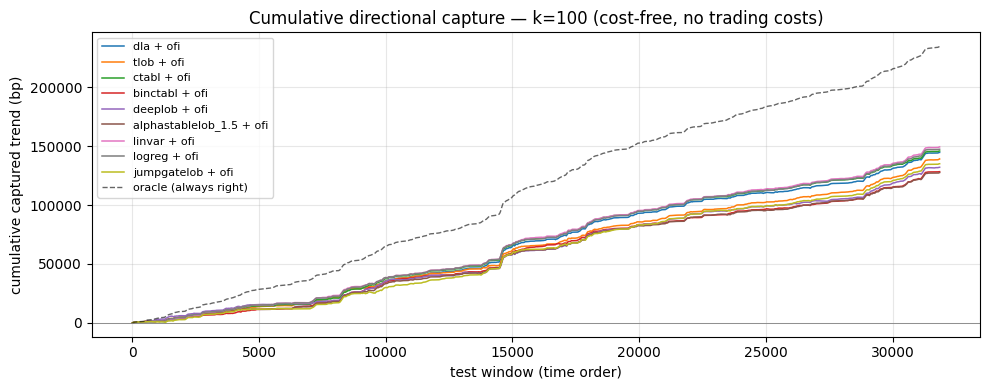

In [16]:
def plot_capture(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    tr = np.nan_to_num(m["trend"])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, tag in enumerate(tags):
        cap = _positions(RESULTS[(tag, k)]["y_pred"]) * tr
        ax.plot(np.cumsum(cap) * 1e4, color=cmap(i % 10), lw=1.1, label=DISPLAY[tag])
    ax.plot(
        np.cumsum(np.abs(tr)) * 1e4,
        "k--",
        lw=1.0,
        alpha=0.6,
        label="oracle (always right)",
    )
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("test window (time order)")
    ax.set_ylabel("cumulative captured trend (bp)")
    ax.set_title(
        f"Cumulative directional capture — k={k} (cost-free, no trading costs)"
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_capture(k)

### Calibration & confidence gating

Left — reliability: mean accuracy per confidence decile vs the diagonal (a
calibrated model can be *sized* by its probability). Middle/right — trade only when
`p_max ≥ τ` **and** the call is directional: per-signal hit rate and capture (bp) as
the confidence gate tightens. A model whose hit rate and capture rise with τ gives a
usable filter for the later trading simulation.


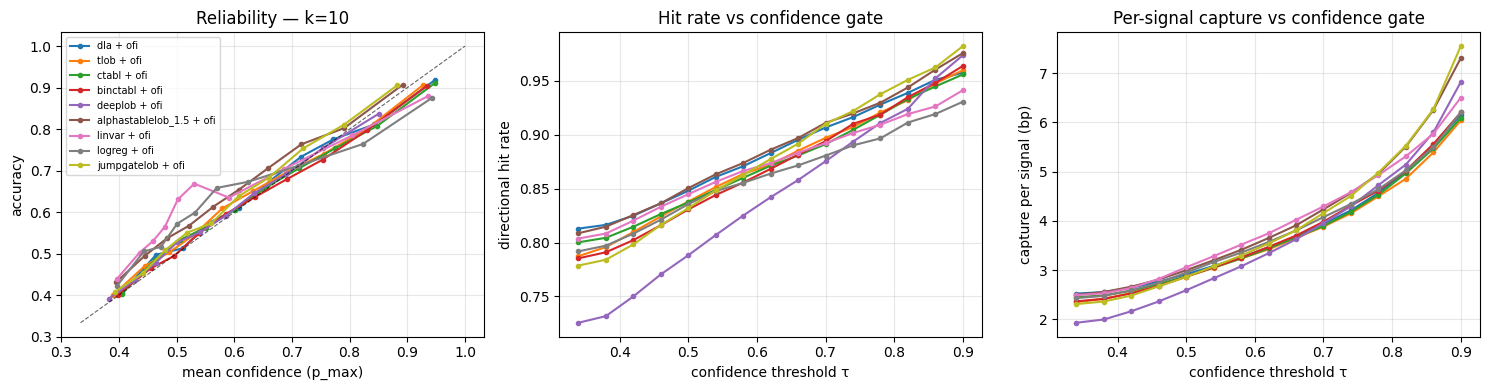

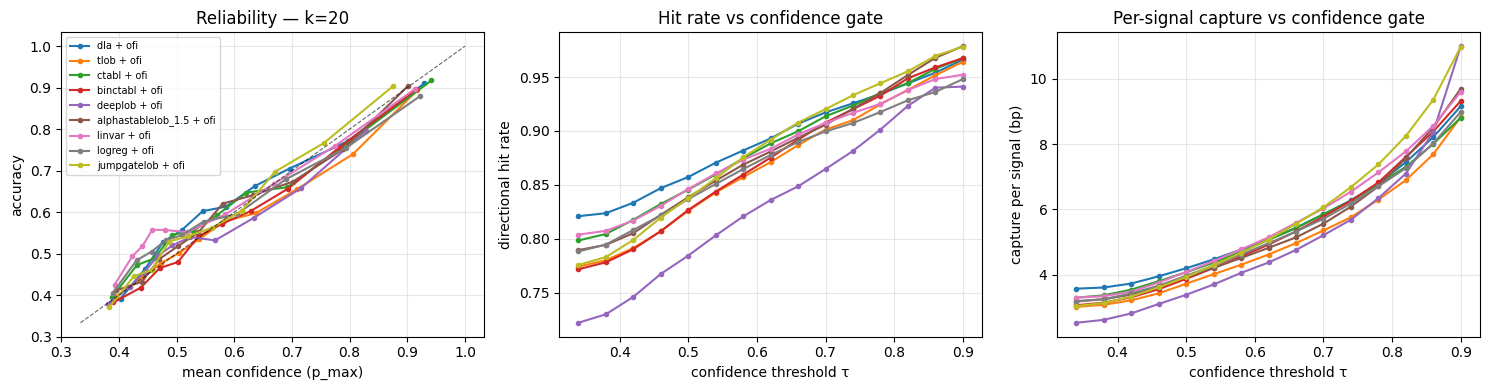

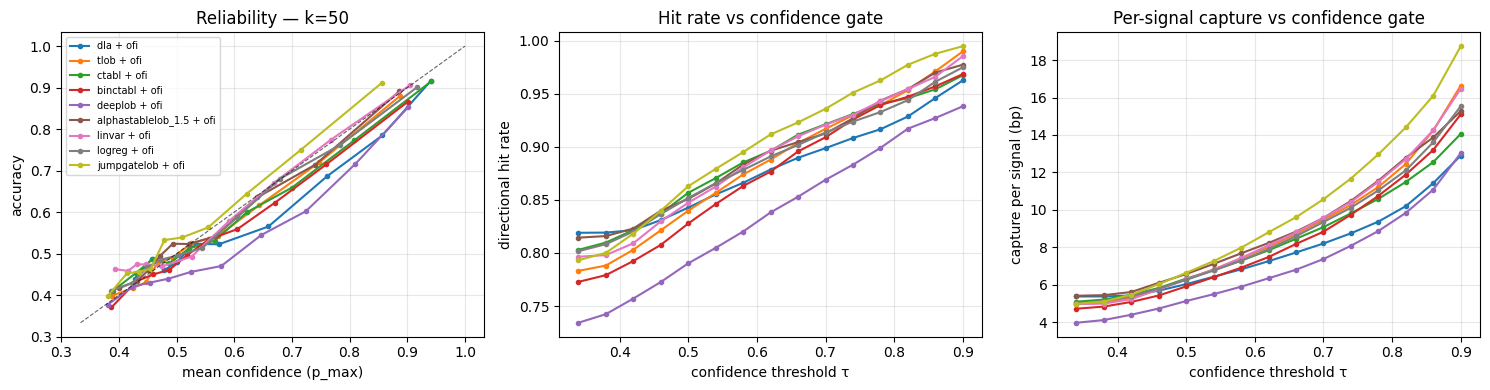

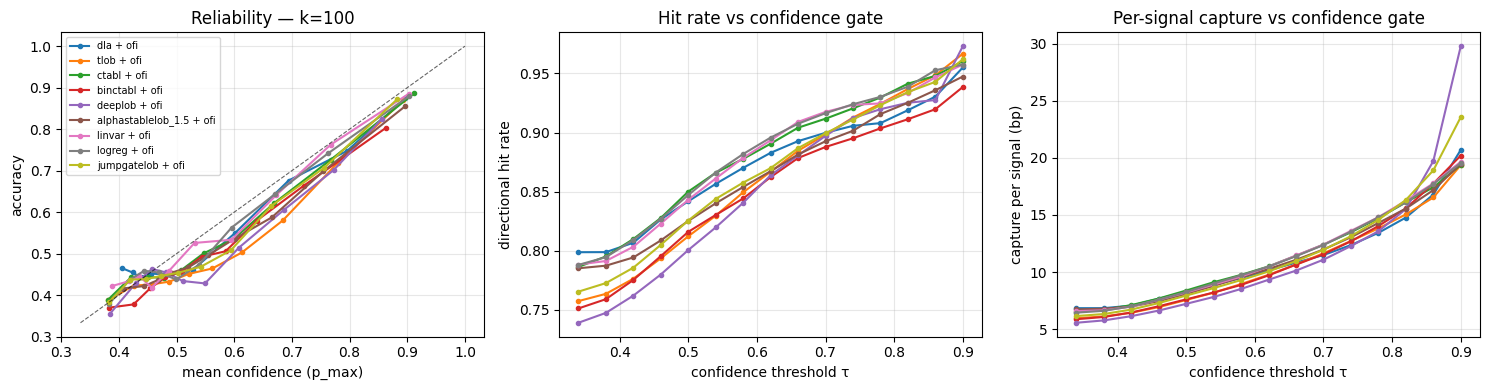

In [17]:
def plot_calibration_gating(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    tr = np.nan_to_num(m["trend"])
    taus = np.linspace(0.34, 0.90, 15)
    cmap = plt.get_cmap("tab10")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        conf = r["probs"].max(1)
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
        edges[-1] += 1e-9
        bi = np.clip(np.digitize(conf, edges) - 1, 0, n_bins - 1)
        xs = [
            conf[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)
        ]
        ys = [
            correct[bi == b].mean() if (bi == b).any() else np.nan
            for b in range(n_bins)
        ]
        axes[0].plot(xs, ys, "o-", ms=3, color=cmap(i % 10), label=DISPLAY[tag])
        pos = _positions(r["y_pred"])
        hit, cap = [], []
        for tau in taus:
            sel = (pos != 0) & (conf >= tau)
            hit.append((np.sign(tr[sel]) == pos[sel]).mean() if sel.any() else np.nan)
            cap.append((pos[sel] * tr[sel]).mean() * 1e4 if sel.any() else np.nan)
        axes[1].plot(taus, hit, "o-", ms=3, color=cmap(i % 10))
        axes[2].plot(taus, cap, "o-", ms=3, color=cmap(i % 10))
    axes[0].plot([1 / 3, 1], [1 / 3, 1], "k--", lw=0.8, alpha=0.6)
    axes[0].set_xlabel("mean confidence (p_max)")
    axes[0].set_ylabel("accuracy")
    axes[0].set_title(f"Reliability — k={k}")
    axes[0].legend(fontsize=7)
    axes[1].set_xlabel("confidence threshold τ")
    axes[1].set_ylabel("directional hit rate")
    axes[1].set_title("Hit rate vs confidence gate")
    axes[2].set_xlabel("confidence threshold τ")
    axes[2].set_ylabel("capture per signal (bp)")
    axes[2].set_title("Per-signal capture vs confidence gate")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_calibration_gating(k)

## 7c. Robustness under injected input noise

The headline metrics average over a test set that is mostly *calm*, which dilutes the
one thing the diffusion models were built for. Here we test that property directly:
take **clean** test windows and inject increasing noise ourselves, identically for every
model, then watch how macro-F1 falls off.

Four corruptions, all at overall scale `σ` (features are z-scored, so `σ≈1` is heavy):
- **gaussian** — `x + σ·ξ` (light-tailed baseline).
- **jump** — the JumpGateLOB training kernel: a Gaussian scale mixture `x + √W·ξ`,
  `W = σ² + Σ Gamma jumps`, `N ~ Poisson(σ)` (discrete, jump-like).
- **student_t** — heavy-tailed `x + σ·t_ν` (Student-t, ν=3, standardised to unit
  variance). This is **neither** diffusion model's training kernel, so it is the
  fairest *unseen heavy-tail* stress test.
- **alpha_stable** — the AlphaStableLOB training kernel: subordinated-Gaussian
  α-stable `x + √W·ξ`, `W = σ²·A`, `A ~ PositiveStable(α/2)` (α=1.7, clipped) —
  genuine power-law tails.

The claim to test: JumpGateLOB / AlphaStableLOB curves should stay **flatter** as `σ`
grows, even if they start lower at `σ=0` — most tellingly under `student_t` (unseen by
both) and each model's own kernel (`jump` / `alpha_stable`). **Fair-test caveat:** the
diffusion models trained on heavy-tailed kernels while DLA/CTABL/DeepLOB never saw
injected noise, so a win here is real *robustness to input corruption* but partly a
training-augmentation effect — read it as "does corruption-aware training buy deployment
robustness," not "is the architecture inherently better."

In [18]:
from torch.utils.data import Subset  # noqa: E402

# --- noise sweep config (reduce ROBUST_N / ROBUST_SIGMAS if too slow) ---------
ROBUST_N = 2500  # test windows subsampled
ROBUST_SIGMAS = [0.0, 0.15, 0.3, 0.5, 0.75, 1.0]  # overall noise scale σ
ROBUST_KINDS = ["gaussian", "jump", "student_t", "alpha_stable"]
SIGMA_FOCUS = 0.5  # σ at which calibration / probs are inspected
JUMP = {"rate": 1.0, "shape": 1.0, "scale": 1.0}  # JumpGateLOB levy kernel
STUDENT_NU = 3.0  # Student-t degrees of freedom (heavier as ν→2); var = ν/(ν-2)
ASTABLE_ALPHA = 1.7  # α-stable stability index (α<2 ⇒ power-law tails)
ASTABLE_CLIP_Q = 0.999  # clip the (infinite-mean) subordinator for stability


def perturb(x, sigma, kind, seed):
    """Deterministic input corruption (identical across models given the seed).

    gaussian     — x + σ·ξ                       (light-tailed baseline)
    jump         — x + √W·ξ, W=σ²+ΣGamma jumps   (JumpGateLOB kernel; discrete)
    student_t    — x + σ·t_ν  (ν=3, unit-var)    (heavy-tailed; *neither* kernel)
    alpha_stable — x + √W·ξ, W=σ²·A, A~S⁺_{α/2}  (AlphaStableLOB kernel; power-law)
    """
    torch.manual_seed(seed)  # reproducible randn + _standard_gamma
    eps = torch.randn_like(x)
    if sigma == 0.0 or kind == "gaussian":
        return x + sigma * eps
    v = (-1,) + (1,) * (x.dim() - 1)

    if kind == "jump":
        b = x.shape[0]
        W = torch.full((b,), sigma * sigma)
        N = torch.poisson(torch.full((b,), JUMP["rate"] * sigma))
        m = N > 0
        if m.any():
            W = W.clone()
            W[m] = W[m] + torch._standard_gamma(N[m] * JUMP["shape"]) * JUMP["scale"]
        return x + W.sqrt().view(v) * eps

    if kind == "student_t":
        # standardised Student-t (unit variance for ν>2) → comparable to gaussian σ
        chi2 = torch._standard_gamma(torch.full_like(x, STUDENT_NU / 2.0)) * 2.0
        t = eps / (chi2 / STUDENT_NU).sqrt()
        t = t * ((STUDENT_NU - 2.0) / STUDENT_NU) ** 0.5
        return x + sigma * t

    if kind == "alpha_stable":
        # positive (β=α/2)-stable subordinator A via Kanter (1975); W = σ²·A
        b = x.shape[0]
        beta = ASTABLE_ALPHA / 2.0
        U = torch.rand(b).clamp(1e-7, 1 - 1e-7) * float(np.pi)
        E = (-torch.log(torch.rand(b).clamp_min(1e-12))).clamp_min(1e-12)
        t1 = torch.sin(beta * U) / torch.sin(U).clamp_min(1e-12).pow(1.0 / beta)
        t2 = (torch.sin((1 - beta) * U) / E).clamp_min(1e-30).pow((1 - beta) / beta)
        A = (t1 * t2).clamp_min(1e-12)
        A = A.clamp_max(torch.quantile(A, ASTABLE_CLIP_Q))
        W = (sigma * sigma) * A
        return x + W.sqrt().view(v) * eps

    raise ValueError(f"unknown kind {kind!r}")


@torch.no_grad()
def run_robust_sweep():
    """macro-F1 vs σ for every (model, horizon, kind); stash probs at SIGMA_FOCUS."""
    rows, probs = [], {}
    for k in HORIZONS:
        try:
            test_ds, _, _ = test_set(k)
        except Exception as e:
            print(f"  k={k}: no test set ({e}) — skipped")
            continue
        rng = np.random.default_rng(k)
        idx = np.sort(
            rng.choice(len(test_ds), min(ROBUST_N, len(test_ds)), replace=False)
        )
        sub = Subset(test_ds, idx.tolist())
        for tag in MODELS:
            path = CHECKPOINTS.get(tag, {}).get(k)
            if not path or not Path(path).exists():
                continue
            model = build_model(tag, load_ckpt(path))
            for kind in ROBUST_KINDS:
                loader = DataLoader(sub, batch_size=BATCH, shuffle=False)
                for sig in ROBUST_SIGMAS:
                    yt, yp, prc = [], [], []
                    for bi, b in enumerate(loader):
                        x = b["x"].float()
                        seed = (
                            int(sig * 1000) + bi * 7 + ROBUST_KINDS.index(kind) * 100003
                        )
                        xp = perturb(x, sig, kind, seed)
                        logits = model.predict({"x": xp, "label": b["label"]}, DEVICE)
                        yp.append(logits.argmax(1).cpu().numpy())
                        yt.append(b["label"].numpy())
                        if kind == "jump" and abs(sig - SIGMA_FOCUS) < 1e-9:
                            prc.append(Fn.softmax(logits, 1).cpu().numpy())
                    yt, yp = np.concatenate(yt), np.concatenate(yp)
                    rows.append(
                        {
                            "model": DISPLAY[tag],
                            "k": k,
                            "kind": kind,
                            "sigma": sig,
                            "macro_f1": f1_score(
                                yt,
                                yp,
                                average="macro",
                                labels=[0, 1, 2],
                                zero_division=0,
                            ),
                        }
                    )
                    if prc:
                        probs[(tag, k)] = (yt, yp, np.concatenate(prc))
            del model
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
        n_k = len({r["model"] for r in rows if r["k"] == k})
        print(f"  k={k}: swept {n_k} models")
    return pd.DataFrame(rows), probs


print(
    f"running noise sweep — {ROBUST_N} windows × {len(ROBUST_SIGMAS)} σ × "
    f"{len(ROBUST_KINDS)} kinds (gaussian/jump/student_t/alpha_stable)…"
)
robust_df, ROBUST_PROBS = run_robust_sweep()
print(f"done — {len(robust_df)} rows")
robust_df.head()

running noise sweep — 2500 windows × 6 σ × 4 kinds (gaussian/jump/student_t/alpha_stable)…
  k=10: swept 9 models
  k=20: swept 9 models
  k=50: swept 9 models
  k=100: swept 9 models
done — 864 rows


,model,k,kind,sigma,macro_f1
0,dla + ofi,10,gaussian,0.0000,0.6613
1,dla + ofi,10,gaussian,0.1500,0.6314
2,dla + ofi,10,gaussian,0.3000,0.5656
3,dla + ofi,10,gaussian,0.5000,0.5051
4,dla + ofi,10,gaussian,0.7500,0.4539


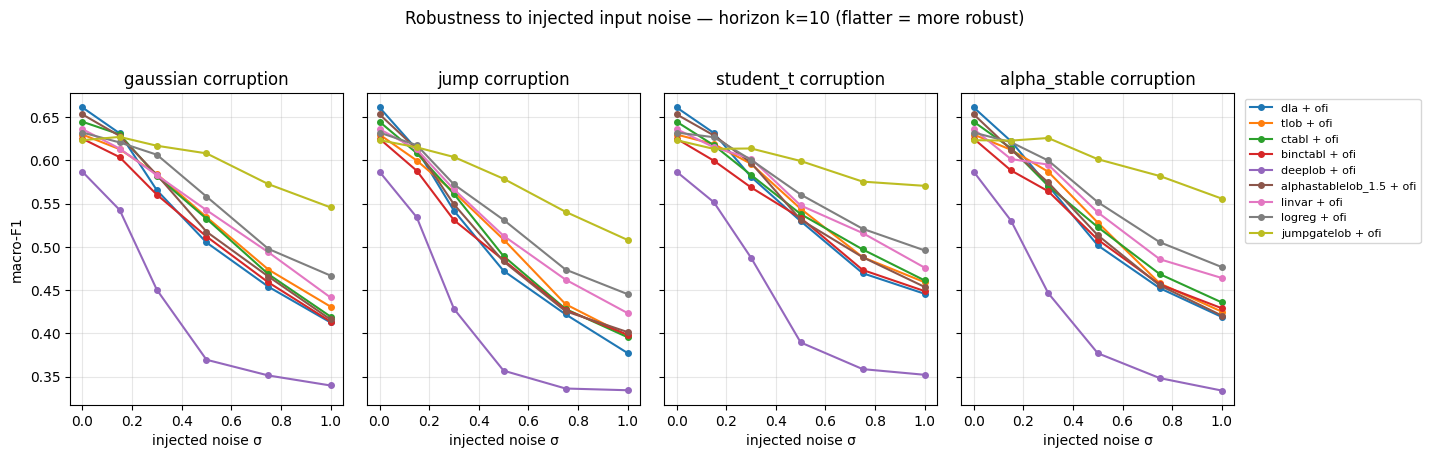

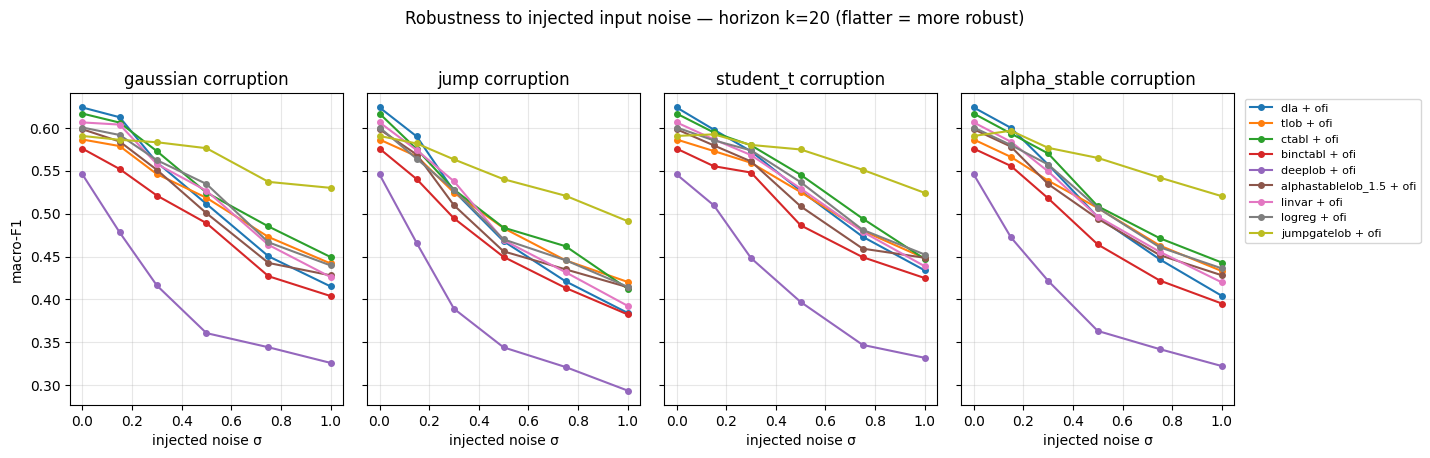

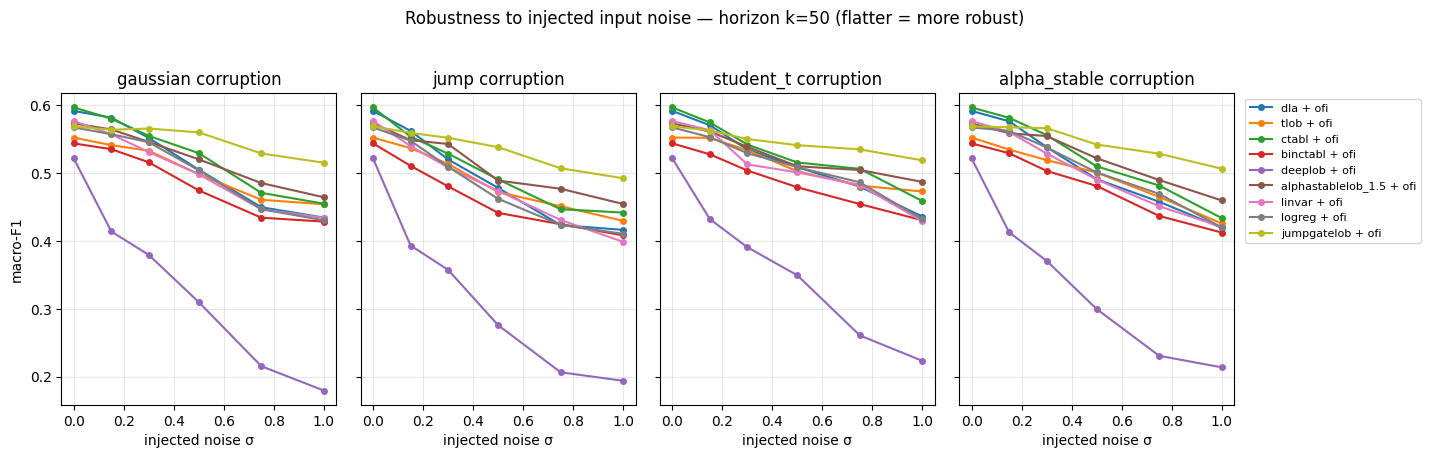

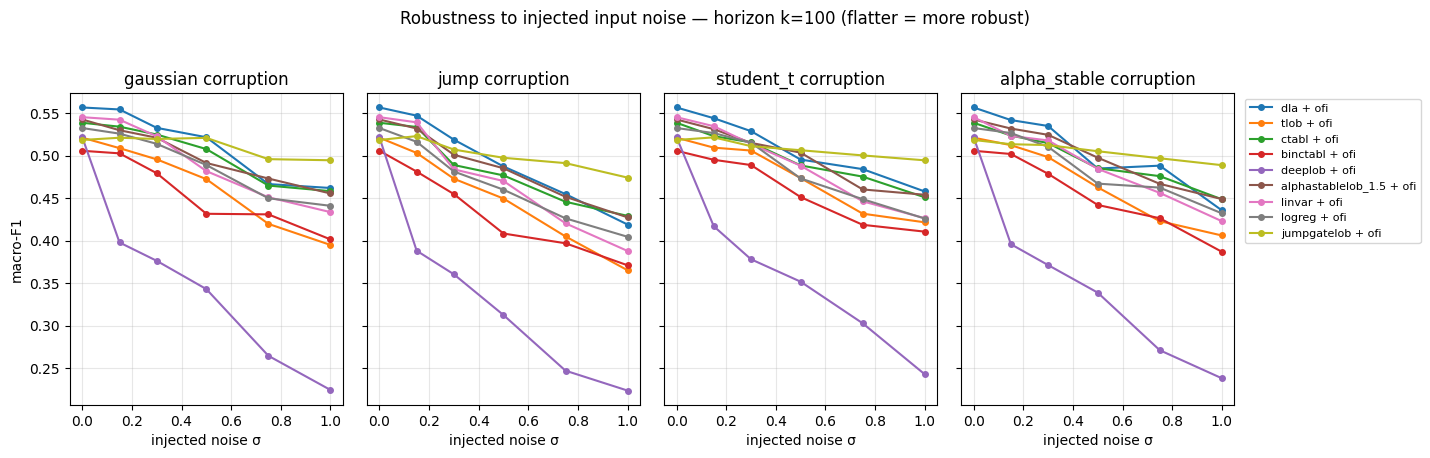


Retention  F1(σ=1.0)/F1(0)  by corruption, mean over horizons (higher = more robust):


kind,gaussian,jump,student_t,alpha_stable,mean
model,,,,,
jumpgatelob + ofi,0.906,0.854,0.916,0.900,0.894
logreg + ofi,0.762,0.718,0.774,0.757,0.753
alphastablelob_1.5 + ofi,0.745,0.717,0.779,0.742,0.746
tlob + ofi,0.752,0.704,0.787,0.738,0.745
ctabl + ofi,0.744,0.701,0.759,0.735,0.734
binctabl + ofi,0.732,0.693,0.762,0.721,0.727
linvar + ofi,0.734,0.678,0.749,0.731,0.723
dla + ofi,0.709,0.656,0.729,0.690,0.696
deeplob + ofi,0.492,0.481,0.529,0.509,0.503


In [19]:
# macro-F1 vs injected noise σ — one figure per horizon, one panel per noise kind
def plot_robust_sweep(k):
    if robust_df.empty or "k" not in robust_df.columns:
        return
    sub = robust_df[robust_df["k"] == k]
    if sub.empty:
        return
    cmap = plt.get_cmap("tab10")
    present = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(sub["model"])]
    n = len(ROBUST_KINDS)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, kind in zip(axes, ROBUST_KINDS):
        d = sub[sub["kind"] == kind]
        for i, name in enumerate(present):
            m = d[d["model"] == name].sort_values("sigma")
            ax.plot(
                m["sigma"], m["macro_f1"], "o-", ms=4, color=cmap(i % 10), label=name
            )
        ax.set_xlabel("injected noise σ")
        ax.set_title(f"{kind} corruption")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("macro-F1")
    axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.suptitle(
        f"Robustness to injected input noise — horizon k={k} (flatter = more robust)",
        y=1.03,
    )
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_robust_sweep(k)

# retention = F1(σ_max)/F1(0) per corruption (mean over horizons); higher = more robust
if not robust_df.empty:
    hi = robust_df["sigma"].max()
    base = (
        robust_df[robust_df["sigma"] == 0.0]
        .groupby(["model", "kind"])["macro_f1"]
        .mean()
    )
    top = (
        robust_df[robust_df["sigma"] == hi]
        .groupby(["model", "kind"])["macro_f1"]
        .mean()
    )
    ret = (top / base.clip(lower=1e-9)).rename("retention").reset_index()
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(ret["model"])]
    piv = ret.pivot(index="model", columns="kind", values="retention").reindex(order)
    piv = piv[[k for k in ROBUST_KINDS if k in piv.columns]]
    piv["mean"] = piv.mean(axis=1)
    print(
        f"\nRetention  F1(σ={hi})/F1(0)  by corruption, mean over horizons "
        f"(higher = more robust):"
    )
    display(
        piv.sort_values("mean", ascending=False)
        .style.background_gradient(cmap="YlGn", axis=None)
        .format("{:.3f}")
    )

### Calibration under noise

Reliability curves computed on **jump-corrupted** inputs (`σ = SIGMA_FOCUS`). A robust
model keeps its probabilities meaningful when the input degrades — accuracy still tracks
confidence along the diagonal. A brittle one becomes *confidently wrong* (points fall
well below the diagonal at high confidence), which is the dangerous failure mode for a
confidence-gated trading rule.


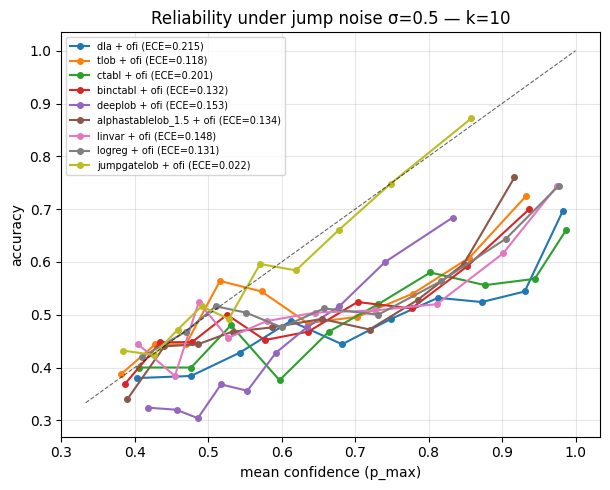

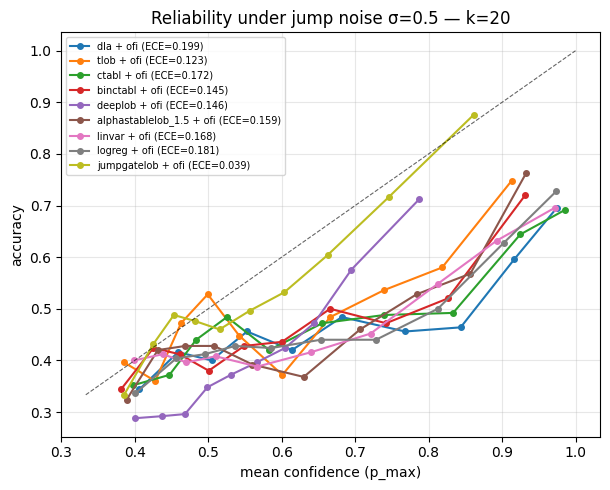

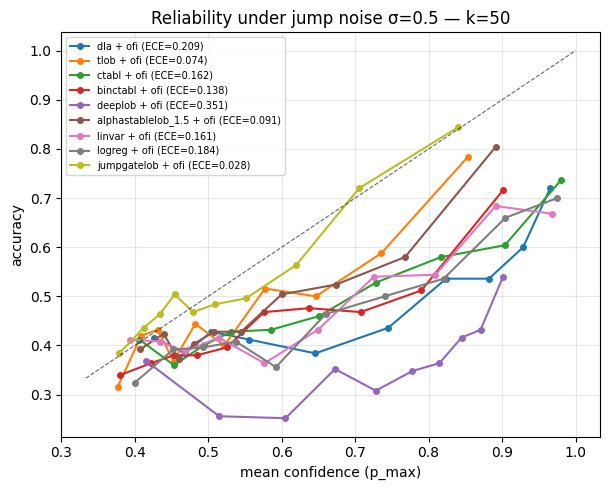

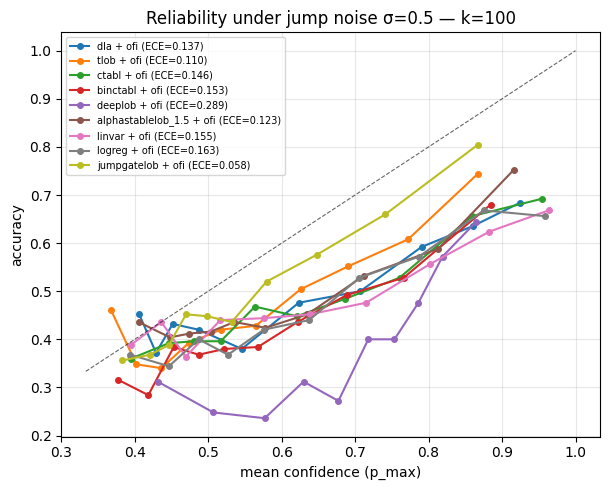

In [20]:
def plot_calibration_under_noise(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in ROBUST_PROBS]
    if not tags:
        return
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(6.2, 5))
    for i, tag in enumerate(tags):
        yt, yp, pr = ROBUST_PROBS[(tag, k)]
        conf = pr.max(1)
        correct = (yt == yp).astype(float)
        edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
        edges[-1] += 1e-9
        bi = np.clip(np.digitize(conf, edges) - 1, 0, n_bins - 1)
        xs = [
            conf[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)
        ]
        ys = [
            correct[bi == b].mean() if (bi == b).any() else np.nan
            for b in range(n_bins)
        ]
        # expected calibration error (bin-weighted |acc − conf|)
        ece = np.nansum(
            [
                (bi == b).mean() * abs(np.nan_to_num(ys[b]) - np.nan_to_num(xs[b]))
                for b in range(n_bins)
            ]
        )
        ax.plot(
            xs,
            ys,
            "o-",
            ms=4,
            color=cmap(i % 10),
            label=f"{DISPLAY[tag]} (ECE={ece:.3f})",
        )
    ax.plot([1 / 3, 1], [1 / 3, 1], "k--", lw=0.8, alpha=0.6)
    ax.set_xlabel("mean confidence (p_max)")
    ax.set_ylabel("accuracy")
    ax.set_title(f"Reliability under jump noise σ={SIGMA_FOCUS} — k={k}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_calibration_under_noise(k)

### Bootstrap confidence intervals on macro-F1

The test set is short (~22 days, one asset), so small macro-F1 gaps may be noise. We
resample the **clean** test windows with replacement (1000×) and report the 95%
interval per model. Overlapping intervals ⇒ the models are statistically
indistinguishable — which reframes "diffusion models rank lower" as "within noise of the
baselines."


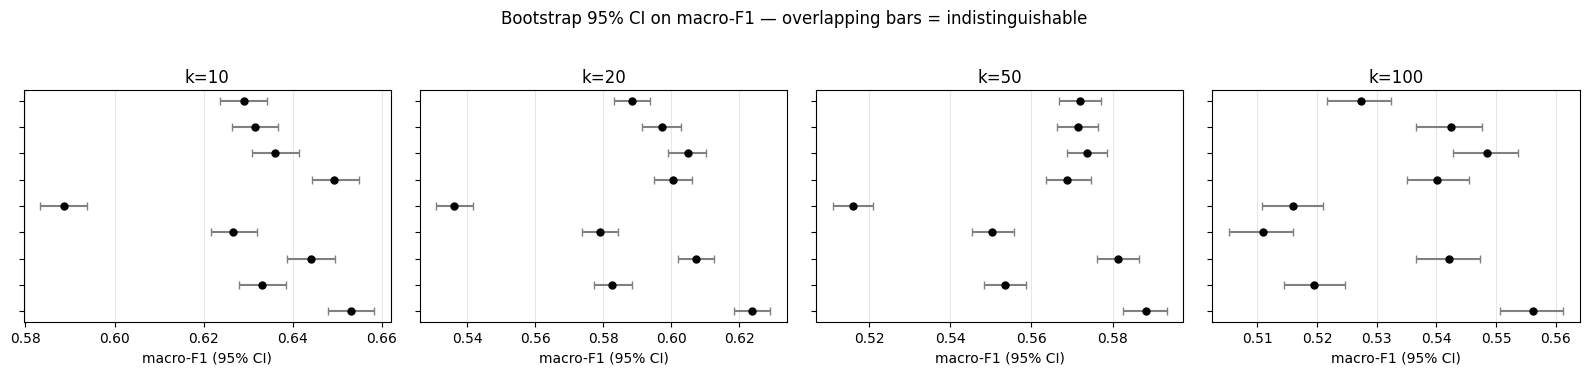

k,10,20,50,100
model,,,,
dla + ofi,0.6530,0.6238,0.5883,0.5561
tlob + ofi,0.6330,0.5826,0.5535,0.5196
ctabl + ofi,0.6440,0.6074,0.5813,0.5422
binctabl + ofi,0.6266,0.5791,0.5504,0.5110
deeplob + ofi,0.5887,0.5362,0.5161,0.5160
alphastablelob_1.5 + ofi,0.6493,0.6006,0.5687,0.5401
linvar + ofi,0.6360,0.6048,0.5738,0.5484
logreg + ofi,0.6315,0.5974,0.5714,0.5424
jumpgatelob + ofi,0.6290,0.5883,0.5720,0.5273


In [21]:
def bootstrap_f1(yt, yp, n=1000, seed=0):
    rng = np.random.default_rng(seed)
    N = len(yt)
    vals = np.empty(n)
    for i in range(n):
        idx = rng.integers(0, N, N)
        vals[i] = f1_score(
            yt[idx], yp[idx], average="macro", labels=[0, 1, 2], zero_division=0
        )
    return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)


boot_rows = []
for (tag, k), r in RESULTS.items():
    mean, lo, hi = bootstrap_f1(r["y_true"], r["y_pred"])
    boot_rows.append({"model": DISPLAY[tag], "k": k, "mean": mean, "lo": lo, "hi": hi})
boot_df = pd.DataFrame(boot_rows)

# forest plot: macro-F1 ± 95% CI per model, one panel per horizon
present = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(boot_df["model"])]
fig, axes = plt.subplots(
    1, len(HORIZONS), figsize=(4 * len(HORIZONS), 3.6), sharey=True
)
axes = np.atleast_1d(axes)
cmap = plt.get_cmap("tab10")
for ax, k in zip(axes, HORIZONS):
    d = boot_df[boot_df["k"] == k].set_index("model").reindex(present).dropna()
    y = np.arange(len(d))
    ax.errorbar(
        d["mean"],
        y,
        xerr=[d["mean"] - d["lo"], d["hi"] - d["mean"]],
        fmt="o",
        color="black",
        ecolor="grey",
        capsize=3,
        ms=5,
    )
    ax.set_yticks(y, d.index if k == HORIZONS[0] else [""] * len(d), fontsize=8)
    ax.set_title(f"k={k}")
    ax.set_xlabel("macro-F1 (95% CI)")
    ax.grid(alpha=0.3, axis="x")
fig.suptitle(
    "Bootstrap 95% CI on macro-F1 — overlapping bars = indistinguishable", y=1.03
)
fig.tight_layout()
plt.show()
boot_df.pivot(index="model", columns="k", values="mean").reindex(present)

## 8. Final model comparison table

Mean macro-F1 across horizons (overall, calm, extreme) plus the financial
aggregates (mean MCC / capture ratio). `robustness` = extreme / calm.


In [22]:
if RESULTS:
    agg = metrics_df.groupby("model")["macro_f1"].mean().rename("macro_f1_mean")
    parts = [agg]
    if not fin_df.empty:
        parts.append(fin_df.groupby("model")[["mcc", "capture_ratio"]].mean())
    ex = extreme_df.groupby("model")[["f1_calm", "f1_extreme"]].mean()
    parts.append(ex)
    summary = pd.concat(parts, axis=1)
    summary["robustness"] = summary["f1_extreme"] / summary["f1_calm"].clip(lower=1e-9)
    summary = summary.sort_values("macro_f1_mean", ascending=False)
    grad_cols = [
        c
        for c in ["macro_f1_mean", "mcc", "capture_ratio", "f1_calm", "f1_extreme"]
        if c in summary.columns
    ]
    display(
        summary.style.background_gradient(cmap="YlGn", subset=grad_cols).format(
            "{:.4f}"
        )
    )
else:
    print("No results — populate CHECKPOINTS in section 2 and re-run.")

,macro_f1_mean,mcc,capture_ratio,f1_calm,f1_extreme,robustness
model,,,,,,
dla + ofi,0.6053,0.4033,0.6271,0.6035,0.6214,1.0296
ctabl + ofi,0.5937,0.3897,0.6281,0.5913,0.6151,1.0404
linvar + ofi,0.5907,0.3871,0.6360,0.5882,0.6133,1.0427
alphastablelob_1.5 + ofi,0.5897,0.3794,0.5987,0.5860,0.6217,1.0608
logreg + ofi,0.5857,0.3805,0.6313,0.5824,0.6144,1.0549
jumpgatelob + ofi,0.5792,0.3715,0.6069,0.5744,0.6210,1.0811
tlob + ofi,0.5722,0.3610,0.6042,0.5686,0.6037,1.0617
binctabl + ofi,0.5668,0.3487,0.5841,0.5630,0.6003,1.0662
deeplob + ofi,0.5393,0.3260,0.5529,0.5363,0.5636,1.0509


In [23]:
# Global knobs for the significance battery. It runs on EVERY (model, horizon)
# in RESULTS — no single target to pick.
H_FWD = None  # forward-return horizon in *windows*; None -> that pair's k
FLAT_THRESHOLD = 0.0  # |score| <= thr counts as "no directional call"
COST_BPS = 5.0  # round-trip cost: half-spread + fees + adverse selection
N_BOOT = 2000  # block-bootstrap resamples
CI = 0.95  # two-sided bootstrap coverage
MEAN_BURN = 250  # burn-in windows before the prevailing mean is trusted
RHO_GRID = [0.0, 0.5, 0.9, 0.95, 0.99]  # AR(1) values swept for breadth deflation
N_REL_BINS = 10  # reliability-diagram / Murphy bins
REL_FOCUS_K = None  # horizon for the reliability-diagram panel; None -> first
print(
    f"significance battery over {len(RESULTS)} (model, horizon) pairs, cost={COST_BPS}bp"
)

significance battery over 36 (model, horizon) pairs, cost=5.0bp


### 9.1 Data-loading stub

`build_eval_frame` assembles the per-decision-point dataframe the tests consume,
straight from this notebook's `RESULTS`/`META`. Columns match the spec:
`ts, score, pred_class, p_down/p_flat/p_up, r_hat, r_fwd, cost`, plus the two
baselines `r_mean` (prevailing-mean, *nested*) and `r_rw` (persistence,
*non-nested*). **To score an external model**, replace the body of this function
with your own dataframe — the rest of the section only touches these columns.

In [24]:
from scipy import stats  # noqa: E402


def _forward_return(mid, centres, h):
    """Log forward mid return over h windows; NaN where the horizon runs off the end."""
    mid = np.asarray(mid, float)
    nxt = centres + h
    ok = nxt < len(mid)
    r = np.full(len(centres), np.nan)
    r[ok] = np.log(mid[nxt[ok]]) - np.log(mid[centres[ok]])
    return r


def build_eval_frame(tag, k, h=None, flat_thr=0.0, cost_bps=COST_BPS):
    """Per-decision-point frame for (tag, k). See section header for column spec.

    r_hat: these are *classifiers* with no native return forecast, so the score
    s = P(up)-P(down) is mapped to return units by a single fixed scale matched to
    the realized-return dispersion (monotone, in-sample). Drop in a genuine model
    point-forecast here if you have one.
    """
    r, m = RESULTS[(tag, k)], META[k]
    h = k if h is None else h
    pr = r["probs"]
    score = pr[:, 2] - pr[:, 0]
    r_fwd = _forward_return(m["mid"], m["centres"], h)
    ss, sr = np.nanstd(score), np.nanstd(r_fwd)
    r_hat = score * (sr / ss if ss > 0 else 0.0)
    ts = np.asarray(m["ts"])[m["centres"]] if "ts" in m else np.arange(len(score))
    df = pd.DataFrame(
        {
            "ts": ts,
            "score": score,
            "pred_class": r["y_pred"],
            "p_down": pr[:, 0],
            "p_flat": pr[:, 1],
            "p_up": pr[:, 2],
            "r_hat": r_hat,
            "r_fwd": r_fwd,
            "cost": cost_bps / 1e4,
        }
    )
    # nested baseline: expanding (out-of-sample) prevailing mean of r_fwd
    rf = df["r_fwd"].to_numpy()
    csum = np.nancumsum(rf)
    cnt = np.cumsum(~np.isnan(rf))
    prev = np.full(len(rf), np.nan)
    prev[1:] = csum[:-1] / np.clip(cnt[:-1], 1, None)
    prev[cnt < MEAN_BURN] = np.nan
    df["r_mean"] = prev
    # non-nested baseline: persistence (previous window's realized fwd return)
    df["r_rw"] = df["r_fwd"].shift(1)
    df["dir_call"] = np.where(
        np.abs(df["score"]) <= flat_thr, 0, np.sign(df["score"])
    ).astype(int)
    return df


def integrated_ac_time(x, max_lag=200):
    """Integrated autocorr time tau = 1 + 2*sum_{l>=1} rho_l (positive part, Sokal).

    Ties the HAC lag and the bootstrap block length to the signal's own memory.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x)
    if denom <= 0 or n < 5:
        return 1.0
    tau, max_lag = 1.0, min(max_lag, n - 1)
    for lag in range(1, max_lag + 1):
        rho = np.dot(x[lag:], x[:-lag]) / denom
        if rho <= 0:  # stop at first non-positive lag
            break
        tau += 2 * rho
    return float(max(tau, 1.0))


# Build one eval frame per (model, horizon), plus its own HAC lag / block length
# (each series gets a lag tied to ITS autocorrelation time and forward horizon).
FRAMES, HACP = {}, {}
for tag, k in RESULTS:
    if META.get(k) is None:
        continue
    fr = build_eval_frame(tag, k, H_FWD, FLAT_THRESHOLD, COST_BPS)
    h_eff = k if H_FWD is None else H_FWD
    ac = int(np.ceil(integrated_ac_time(fr["score"])))
    FRAMES[(tag, k)] = fr
    HACP[(tag, k)] = {
        "h_eff": h_eff,
        "hac_L": int(max(ac, h_eff - 1, 1)),
        "block": int(max(ac, h_eff, 1)),
    }
print(f"built {len(FRAMES)} eval frames")
if FRAMES:
    ex = next(iter(FRAMES))
    print(
        f"example {ex}: rows={len(FRAMES[ex])}  "
        f"usable r_fwd={int(FRAMES[ex]['r_fwd'].notna().sum())}  "
        f"HAC_L={HACP[ex]['hac_L']}  block={HACP[ex]['block']}"
    )
    display(FRAMES[ex].head())

built 36 eval frames
example ('dla', 10): rows=31949  usable r_fwd=31949  HAC_L=11  block=11


,ts,score,pred_class,p_down,p_flat,p_up,r_hat,r_fwd,cost,r_mean,r_rw,dir_call
0,1783661820000000,0.8503,2,0.0421,0.0654,0.8924,0.0008,-0.0008,0.0005,NaN,NaN,1
1,1783661830000000,0.9458,2,0.0136,0.0271,0.9594,0.0009,-0.0016,0.0005,NaN,-0.0008,1
2,1783661840000000,0.8996,2,0.0250,0.0504,0.9246,0.0009,-0.0012,0.0005,NaN,-0.0016,1
3,1783661850000000,0.8315,2,0.0457,0.0770,0.8772,0.0008,-0.0012,0.0005,NaN,-0.0012,1
4,1783661860000000,0.8841,2,0.0318,0.0523,0.9159,0.0008,-0.0012,0.0005,NaN,-0.0012,1


### 9.2 Statistical skill

Directional and forecast-comparison tests. `hac_lrv` is the shared Newey–West
long-run variance used by DM and CW; the lag `HAC_L` is tied to the signal's
autocorrelation time so both dependence corrections are consistent.

In [25]:
def hac_lrv(x, L):
    """Newey-West (Bartlett) long-run variance of one observation of x.

    gamma_0 + 2 * sum_{l=1..L} (1 - l/(L+1)) gamma_l. Shared by DM and CW so their
    SEs reflect the heavy serial correlation of tick-level loss differentials.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan
    x = x - x.mean()
    lrv = np.dot(x, x) / n
    for lag in range(1, min(L, n - 1) + 1):
        w = 1.0 - lag / (L + 1.0)
        lrv += 2.0 * w * np.dot(x[lag:], x[:-lag]) / n
    return max(lrv, 1e-24)


def hac_se_mean(x, L):
    """HAC standard error of the sample mean of x."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    return np.sqrt(hac_lrv(x, L) / len(x))


def pesaran_timmermann(pred_sign, real_ret):
    """PT (1992) directional-accuracy test. pred_sign in {-1,0,+1}; flats dropped."""
    mask = ~np.isnan(real_ret) & (pred_sign != 0)
    x = (pred_sign[mask] > 0).astype(float)  # predicted up
    y = (real_ret[mask] > 0).astype(float)  # realized up
    n = len(y)
    if n < 10:
        return {"hit": np.nan, "benchmark": np.nan, "stat": np.nan, "p": np.nan, "n": n}
    P = float(np.mean(x == y))  # hit rate = sign agreement
    Py, Px = y.mean(), x.mean()
    Pstar = Py * Px + (1 - Py) * (1 - Px)  # independence benchmark
    var_P = Pstar * (1 - Pstar) / n
    var_Pstar = (
        ((2 * Py - 1) ** 2) * Px * (1 - Px) / n
        + ((2 * Px - 1) ** 2) * Py * (1 - Py) / n
        + 4 * Py * Px * (1 - Py) * (1 - Px) / n**2
    )
    denom = var_P - var_Pstar
    stat = (P - Pstar) / np.sqrt(denom) if denom > 0 else np.nan
    p = float(1 - stats.norm.cdf(stat)) if np.isfinite(stat) else np.nan
    return {"hit": P, "benchmark": Pstar, "stat": stat, "p": p, "n": n}


def henriksson_merton(pred_sign, real_ret):
    """HM market-timing skill: p_up + p_down - 1, hypergeometric significance."""
    mask = ~np.isnan(real_ret) & (pred_sign != 0)
    ps, rr = pred_sign[mask], real_ret[mask]
    up, dn = rr > 0, rr < 0
    n1, n2 = int(up.sum()), int(dn.sum())
    if n1 < 5 or n2 < 5:
        return {
            "skill": np.nan,
            "p_up": np.nan,
            "p_down": np.nan,
            "stat": np.nan,
            "p": np.nan,
        }
    p_up = float(np.mean(ps[up] > 0))  # correct given up
    p_dn = float(np.mean(ps[dn] < 0))  # correct given down
    n = n1 + n2
    N1 = int((ps > 0).sum())  # predicted up
    n11 = int(((ps > 0) & up).sum())  # correct up
    E = N1 * n1 / n
    V = N1 * n1 * (n - N1) * (n - n1) / (n**2 * (n - 1))
    stat = (n11 - E) / np.sqrt(V) if V > 0 else np.nan
    p = float(1 - stats.norm.cdf(stat)) if np.isfinite(stat) else np.nan
    return {
        "skill": p_up + p_dn - 1,
        "p_up": p_up,
        "p_down": p_dn,
        "stat": stat,
        "p": p,
    }


def diebold_mariano(r, f1, f2, L, h=1):
    """DM squared-error test, model f1 vs NON-NESTED baseline f2, HAC SE + HLN fix.

    d = e1^2 - e2^2; a significantly negative mean => model f1 has lower loss.
    """
    m = ~np.isnan(r) & ~np.isnan(f1) & ~np.isnan(f2)
    e1, e2 = r[m] - f1[m], r[m] - f2[m]
    d = e1**2 - e2**2
    n = len(d)
    if n < 10:
        return {"dbar": np.nan, "stat": np.nan, "p": np.nan, "n": n}
    se = hac_se_mean(d, L)
    stat = d.mean() / se if se > 0 else np.nan
    stat *= np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)  # Harvey-Leybourne-Newbold
    p = float(2 * (1 - stats.norm.cdf(abs(stat)))) if np.isfinite(stat) else np.nan
    return {"dbar": float(d.mean()), "stat": stat, "p": p, "n": n}


def clark_west(r, f_unrestr, f_restr, L):
    """CW test, model f_unrestr vs NESTED baseline f_restr (e.g. prevailing mean).

    f = (r - f_restr)^2 - [(r - f_unrestr)^2 - (f_restr - f_unrestr)^2]. The last
    term strips the estimation-noise penalty that biases plain DM against the
    larger model. One-sided: fbar>0 => the extra structure earns its keep OOS.
    """
    m = ~np.isnan(r) & ~np.isnan(f_unrestr) & ~np.isnan(f_restr)
    r_, fu, fr = r[m], f_unrestr[m], f_restr[m]
    f = (r_ - fr) ** 2 - ((r_ - fu) ** 2 - (fr - fu) ** 2)
    n = len(f)
    if n < 10:
        return {"fbar": np.nan, "stat": np.nan, "p": np.nan, "n": n}
    se = hac_se_mean(f, L)
    stat = f.mean() / se if se > 0 else np.nan
    p = float(1 - stats.norm.cdf(stat)) if np.isfinite(stat) else np.nan
    return {"fbar": float(f.mean()), "stat": stat, "p": p, "n": n}


def campbell_thompson_r2(r, f_model, f_mean):
    """OOS R^2 vs the prevailing mean; positive => model beats the running mean."""
    m = ~np.isnan(r) & ~np.isnan(f_model) & ~np.isnan(f_mean)
    num = np.sum((r[m] - f_model[m]) ** 2)
    den = np.sum((r[m] - f_mean[m]) ** 2)
    return float(1 - num / den) if den > 0 else np.nan

### 9.3 Economic value

Information coefficient, Fundamental Law with breadth deflation, conditional
separation, break-even cost, and calibration. Bootstrap CIs use circular blocks
of length `BLOCK_LEN` (the same autocorrelation time that set `HAC_L`).

In [26]:
def block_bootstrap_ci(func, arrays, block, n_boot=None, ci=None, seed=0):
    """Circular-block-bootstrap CI for a statistic of one or more aligned arrays."""
    n_boot = N_BOOT if n_boot is None else n_boot
    ci = CI if ci is None else ci
    rng = np.random.default_rng(seed)
    arrays = [np.asarray(a, float) for a in arrays]
    n = len(arrays[0])
    nb = int(np.ceil(n / block))
    vals = []
    for _ in range(n_boot):
        starts = rng.integers(0, n, nb)
        idx = np.concatenate([(np.arange(s, s + block) % n) for s in starts])[:n]
        v = func(*[a[idx] for a in arrays])
        if np.isfinite(v):
            vals.append(v)
    vals = np.array(vals)
    lo, hi = np.percentile(vals, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return float(np.mean(vals)), float(lo), float(hi)


def boot_group_diff(a, b, block, n_boot=None, ci=None, seed=3):
    """Block-bootstrap CI for mean(a) - mean(b) (each group resampled separately)."""
    n_boot = N_BOOT if n_boot is None else n_boot
    ci = CI if ci is None else ci
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan

    def bmean(x):
        n = len(x)
        nb = int(np.ceil(n / block))
        s = rng.integers(0, n, nb)
        idx = np.concatenate([(np.arange(t, t + block) % n) for t in s])[:n]
        return x[idx].mean()

    d = np.array([bmean(a) - bmean(b) for _ in range(n_boot)])
    lo, hi = np.percentile(d, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return float(d.mean()), float(lo), float(hi)


def _pearson(a, b):
    m = ~np.isnan(a) & ~np.isnan(b)
    return float(np.corrcoef(a[m], b[m])[0, 1]) if m.sum() > 2 else np.nan


def _spearman(a, b):
    m = ~np.isnan(a) & ~np.isnan(b)
    return float(stats.spearmanr(a[m], b[m]).correlation) if m.sum() > 2 else np.nan


def jonckheere_terpstra(groups):
    """JT trend test for monotone increase across ordered groups (normal approx)."""
    groups = [np.asarray(g, float) for g in groups]
    groups = [g[~np.isnan(g)] for g in groups]
    ns = np.array([len(g) for g in groups])
    N = ns.sum()
    JT = 0.0
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            diff = groups[j][:, None] - groups[i][None, :]  # Mann-Whitney count
            JT += np.sum(diff > 0) + 0.5 * np.sum(diff == 0)
    mu = (N**2 - np.sum(ns**2)) / 4.0
    var = (N**2 * (2 * N + 3) - np.sum(ns**2 * (2 * ns + 3))) / 72.0
    z = (JT - mu) / np.sqrt(var) if var > 0 else np.nan
    p = float(1 - stats.norm.cdf(z)) if np.isfinite(z) else np.nan  # one-sided (up)
    return {"JT": float(JT), "z": float(z) if np.isfinite(z) else np.nan, "p": p}


def brier_multiclass(probs, y):
    oh = np.eye(probs.shape[1])[y]
    return float(np.mean(np.sum((probs - oh) ** 2, axis=1)))


def murphy_decomposition(f, o, n_bins=None):
    """Binary Brier = Reliability - Resolution + Uncertainty (Murphy 1973).

    f = forecast prob, o in {0,1}. reliability lower is better; resolution higher.
    """
    n_bins = N_REL_BINS if n_bins is None else n_bins
    edges = np.linspace(0, 1, n_bins + 1)
    edges[-1] += 1e-9
    b = np.clip(np.digitize(f, edges) - 1, 0, n_bins - 1)
    obar = o.mean()
    rel = res = 0.0
    xs, ys, ns = [], [], []
    for k in range(n_bins):
        mask = b == k
        nk = int(mask.sum())
        if nk == 0:
            continue
        fk, ok = f[mask].mean(), o[mask].mean()
        rel += nk * (fk - ok) ** 2
        res += nk * (ok - obar) ** 2
        xs.append(fk)
        ys.append(ok)
        ns.append(nk)
    n = len(f)
    return {
        "reliability": rel / n,
        "resolution": res / n,
        "uncertainty": float(obar * (1 - obar)),
        "brier": float(np.mean((f - o) ** 2)),
        "bins": (np.array(xs), np.array(ys), np.array(ns)),
    }

In [ ]:
# Run every statistical + economic metric on every (model, horizon). Results land
# in SIG[(tag, k)] (full dicts) and SIG_ROWS (one tidy record per pair).
def run_significance(tag, k):
    F = FRAMES[(tag, k)]
    hp = HACP[(tag, k)]
    L, block, h = hp["hac_L"], hp["block"], hp["h_eff"]
    ps, rf = F["dir_call"].to_numpy(), F["r_fwd"].to_numpy()
    rhat, rrw, rmean = (
        F["r_hat"].to_numpy(),
        F["r_rw"].to_numpy(),
        F["r_mean"].to_numpy(),
    )
    out = {}
    out["PT"] = pesaran_timmermann(ps, rf)
    out["HM"] = henriksson_merton(ps, rf)
    out["DM_rw"] = diebold_mariano(rf, rhat, rrw, L, h=h)
    out["CW"] = clark_west(rf, rhat, rmean, L)
    out["CT_R2"] = campbell_thompson_r2(rf, rhat, rmean)

    sc = F["score"].to_numpy()
    m = ~np.isnan(sc) & ~np.isnan(rf)
    sc_, rf_ = sc[m], rf[m]
    out["IC_pearson"] = (
        _pearson(sc_, rf_),
        *block_bootstrap_ci(_pearson, (sc_, rf_), block, seed=1)[1:],
    )
    out["IC_spearman"] = (
        _spearman(sc_, rf_),
        *block_bootstrap_ci(_spearman, (sc_, rf_), block, seed=2)[1:],
    )
    ic0 = _pearson(sc_, rf_)
    rho_hat = _pearson(sc_[1:], sc_[:-1])
    flam_rows = []
    for rho in sorted(set(RHO_GRID + [round(float(rho_hat), 3)])):
        defl = (1 - rho) / (1 + rho)
        br_eff = len(sc_) * defl
        flam_rows.append(
            {
                "rho": rho,
                "breadth_defl": defl,
                "BR_eff": br_eff,
                "IR": ic0 * np.sqrt(max(br_eff, 0.0)),
            }
        )
    out["FLAM"] = {
        "ic": ic0,
        "rho_hat": float(rho_hat),
        "table": pd.DataFrame(flam_rows),
    }

    pc = F["pred_class"].to_numpy()
    grp = {c: rf[(pc == c) & ~np.isnan(rf)] for c in (0, 1, 2)}
    edge = boot_group_diff(grp[2], grp[0], block)
    out["SEP"] = {
        "means_bp": {
            c: float(np.nanmean(grp[c]) * 1e4) if len(grp[c]) else np.nan for c in grp
        },
        "edge_bp": (edge[0] * 1e4, edge[1] * 1e4, edge[2] * 1e4),
        "JT": jonckheere_terpstra([grp[0], grp[1], grp[2]]),
    }

    c = float(F["cost"].iloc[0])
    dcall = F["dir_call"].to_numpy()
    dmask = (dcall != 0) & ~np.isnan(rf)
    pnl = dcall[dmask] * rf[dmask]
    up_mask = (pc == 2) & ~np.isnan(rf)
    up_move = float(np.nanmean(rf[up_mask])) if up_mask.any() else np.nan
    rhat_mag = np.abs(rhat[dmask])
    clears = float(np.mean(rhat_mag > c)) if len(rhat_mag) else np.nan
    wins, losses = pnl[pnl > 0], -pnl[pnl < 0]
    W = wins.mean() if len(wins) else np.nan
    Lm = losses.mean() if len(losses) else np.nan
    p_star = (Lm + c) / (W + Lm) if np.isfinite(W + Lm) and (W + Lm) > 0 else np.nan
    out["BE"] = {
        "up_move_bp": up_move * 1e4,
        "cost_bp": c * 1e4,
        "frac_clears": clears,
        "W_bp": W * 1e4,
        "L_bp": Lm * 1e4,
        "p_star": float(p_star) if np.isfinite(p_star) else np.nan,
        "hit": float(np.mean(pnl > 0)) if len(pnl) else np.nan,
    }

    probs = RESULTS[(tag, k)]["probs"]
    yv = RESULTS[(tag, k)]["y_true"]
    out["BRIER_MC"] = brier_multiclass(probs, yv)
    out["MURPHY"] = murphy_decomposition(probs[:, 2], (yv == 2).astype(float))
    return out


SIG, SIG_ROWS = {}, []
for tag, k in sorted(RESULTS, key=lambda tk: (tk[1], tk[0])):
    if (tag, k) not in FRAMES:
        continue
    r = run_significance(tag, k)
    SIG[(tag, k)] = r
    SIG_ROWS.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "pt_hit": r["PT"]["hit"],
            "pt_p": r["PT"]["p"],
            "hm_skill": r["HM"]["skill"],
            "hm_p": r["HM"]["p"],
            "dm_dbar": r["DM_rw"]["dbar"],
            "dm_p": r["DM_rw"]["p"],
            "cw_fbar": r["CW"]["fbar"],
            "cw_p": r["CW"]["p"],
            "ct_r2_pct": r["CT_R2"] * 100,
            "ic_pearson": r["IC_pearson"][0],
            "ic_spearman": r["IC_spearman"][0],
            "ir_rho_hat": float(
                r["FLAM"]["table"].iloc[
                    (r["FLAM"]["table"]["rho"] - r["FLAM"]["rho_hat"]).abs().idxmin()
                ]["IR"]
            ),
            "rho_hat": r["FLAM"]["rho_hat"],
            "edge_bp": r["SEP"]["edge_bp"][0],
            "jt_p": r["SEP"]["JT"]["p"],
            "be_pstar": r["BE"]["p_star"],
            "be_hit": r["BE"]["hit"],
            "frac_clears": r["BE"]["frac_clears"],
            "brier_mc": r["BRIER_MC"],
            "reliability": r["MURPHY"]["reliability"],
            "resolution": r["MURPHY"]["resolution"],
        }
    )
sig_df = pd.DataFrame(SIG_ROWS)
print(f"scored {len(SIG)} (model, horizon) pairs")
sig_df

> **On the tiny $R^2_{\text{OOS}}$.** At LOB frequency a Campbell–Thompson
> $R^2$ below ~1% is *expected*, not a failure: forward mid returns are almost
> pure noise, so even a real edge explains little variance. What matters is
> whether that sliver is (a) statistically robust (DM/CW above) and (b)
> economically large after the trade multiplier — quantified in the economic
> layer next.

> **Calibration is only load-bearing if you size on probabilities.** If the
> strategy just acts on the argmax class, skip the Brier / Murphy block; it
> matters when `p_up` drives position size, where a well-resolved, low-reliability
> forecast can be scaled and a miscalibrated one cannot.

In [ ]:
# Reliability diagrams (up-vs-rest) — one panel per model at a focus horizon.
# Only meaningful for probability-sized strategies.
if SIG:
    ks = sorted({k for _, k in SIG})
    focus_k = REL_FOCUS_K if REL_FOCUS_K in ks else ks[0]
    tags = [t for t in MODELS if (t, focus_k) in SIG]
    if tags:
        ncol = min(4, len(tags))
        nrow = int(np.ceil(len(tags) / ncol))
        fig, axes = plt.subplots(
            nrow, ncol, figsize=(3.4 * ncol, 3.4 * nrow), squeeze=False
        )
        for ax in axes.flat:
            ax.axis("off")
        for ax, tag in zip(axes.flat, tags):
            ax.axis("on")
            mp = SIG[(tag, focus_k)]["MURPHY"]
            xs, ys, ns = mp["bins"]
            ax.plot([0, 1], [0, 1], "k--", lw=1)
            if len(ns):
                ax.scatter(
                    xs, ys, s=15 + 200 * (ns / ns.max()), color="#1f77b4", zorder=3
                )
            ax.set_title(
                f"{DISPLAY[tag]}\nrel={mp['reliability']:.4f} "
                f"res={mp['resolution']:.4f}",
                fontsize=8,
            )
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel("forecast P(up)", fontsize=8)
            ax.set_ylabel("emp. freq(up)", fontsize=8)
        fig.suptitle(f"Reliability (up-vs-rest) — horizon k={focus_k}", y=1.02)
        plt.tight_layout()
        plt.show()

### 9.4 Summary tables (all models × horizons)

One pivot per headline metric (rows = model, cols = horizon). Statistical tests
also print a companion p-value pivot so significance is read alongside the point
estimate.

In [ ]:
if not sig_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(sig_df["model"])]

    def pivot(col, fmt="{:.4f}", cmap="YlGn"):
        piv = sig_df.pivot(index="model", columns="k", values=col).reindex(order)
        return piv.style.background_gradient(cmap=cmap, axis=None).format(fmt)

    # value + p-value pairs for the statistical tests
    stat_specs = [
        ("Pesaran-Timmermann hit rate", "pt_hit", "pt_p"),
        ("Henriksson-Merton skill", "hm_skill", "hm_p"),
        ("Diebold-Mariano dbar (vs persistence)", "dm_dbar", "dm_p"),
        ("Clark-West fbar (vs prev-mean)", "cw_fbar", "cw_p"),
    ]
    for title, vcol, pcol in stat_specs:
        print(f"\n=== {title} — value (rows=model, cols=k) ===")
        display(pivot(vcol))
        print("    p-value")
        display(
            sig_df.pivot(index="model", columns="k", values=pcol)
            .reindex(order)
            .style.background_gradient(cmap="Reds_r", axis=None, vmin=0, vmax=0.1)
            .format("{:.4g}")
        )

    # single-table economic / directional metrics
    econ_specs = [
        ("Campbell-Thompson OOS R^2 (%)", "ct_r2_pct"),
        ("IC Pearson", "ic_pearson"),
        ("IC Spearman", "ic_spearman"),
        ("Implied IR @ rho_hat (breadth-deflated)", "ir_rho_hat"),
        ("Edge E[r|up]-E[r|down] (bp)", "edge_bp"),
        ("Jonckheere-Terpstra p (monotone)", "jt_p"),
        ("Break-even hit p*", "be_pstar"),
        ("Realized directional hit rate", "be_hit"),
        ("Frac predictions clearing cost", "frac_clears"),
        ("Brier reliability (lower better)", "reliability"),
        ("Brier resolution (higher better)", "resolution"),
    ]
    for title, col in econ_specs:
        print(f"\n=== {title} (rows=model, cols=k) ===")
        cmap = "Reds_r" if col == "jt_p" else "YlGn"
        fmt = "{:.4g}" if col in ("jt_p",) else "{:.4f}"
        display(pivot(col, fmt=fmt, cmap=cmap))
else:
    print("No results — run the sections above first.")

### 9.5 What a pass looks like — per metric

Each line states the pass condition and the claim it licenses.

- **Pesaran–Timmermann** — *pass:* `p < 0.05` and hit > benchmark. *Claim:* the
  predicted direction and the realized sign are dependent — genuine directional
  information, not the marginal class mix.
- **Henriksson–Merton** — *pass:* skill `> 0` with `p < 0.05`. *Claim:* the model
  times **both** sides (its up-hit and down-hit rates jointly beat coin-flipping),
  not just one lucky regime.
- **Diebold–Mariano** — *pass:* `dbar < 0` with `p < 0.05`. *Claim:* the model's
  squared forecast error is reliably below the persistence baseline's — lower loss
  than a non-nested competitor, beyond sampling noise.
- **Clark–West** — *pass:* `fbar > 0` with one-sided `p < 0.05`. *Claim:* the
  model beats the nested prevailing-mean forecast out-of-sample *after* removing
  the estimation-noise advantage — the extra structure earns its keep, not
  overfitting.
- **Campbell–Thompson OOS $R^2$** — *pass:* `> 0` (even ~0.1–1%). *Claim:* the
  model adds predictive information over the running mean; magnitude is expected
  to be tiny at LOB frequency — economic size is judged below, not here.
- **Information coefficient** — *pass:* CI excludes 0. *Claim:* score and forward
  return are monotonically related (Spearman) / linearly related (Pearson) beyond
  autocorrelation-inflated noise.
- **Fundamental Law (IR)** — *pass:* deflated IR stays economically meaningful
  (rule-of-thumb `> 0.5`) at the *estimated* `rho_hat`, not just at `rho=0`.
  *Claim:* after honestly discounting breadth for signal persistence, the implied
  information ratio is still worth harvesting.
- **Conditional separation / Jonckheere–Terpstra** — *pass:* edge CI excludes 0
  **and** JT `p < 0.05`. *Claim:* mean forward return increases monotonically
  down→flat→up — the classes sort future returns in the right order.
- **Break-even cost** — *pass:* realized hit `> p*` and a non-trivial fraction of
  calls clear the cost hurdle. *Claim:* the edge survives the round-trip cost —
  the signal is tradeable, not just correlated.
- **Calibration (Brier / Murphy)** — *pass:* low reliability, positive resolution,
  reliability curve near the diagonal. *Claim:* `p_up` can be trusted for position
  **sizing**, not only for its argmax label.